# Cetacean MLP — Calibrated LODO (Vector Scaling)

Leave-One-Dataset-Out for label levels 1, 2, and 4 with three prediction strategies:

- **argmax** — standard softmax argmax (baseline)
- **temperature** — single scalar T, `softmax(logits/T)`, fit on full val
- **vector scaling** — per-class `w_c * logit_c + b_c`, fit on species-positive
  val rows (L4/L2) or full val (L1 binary — species-only filtering degenerates
  for 2-class problems)

### Inter-species confusion definition (corrected)

A prediction counts as inter-species confusion if:
- the **true** label is a species (not background), AND
- the **predicted** label is ANY species in the training vocabulary — including
  species that have zero rows in the test fold.

Predicting Globicephala when the test set only has Tursiops is a confusion error.
We additionally report `sp_hallucination_rate`: the fraction of species test rows
where the prediction is a species absent from the test fold entirely.

**Rule:** the test set is never used for calibration.

## 0. Setup

In [1]:
import os, sys, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    accuracy_score, balanced_accuracy_score,
)
from sklearn.model_selection import GroupShuffleSplit

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
np.random.seed(42); torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {DEVICE}  torch: {torch.__version__}")

device: cuda  torch: 2.5.1+cu121


In [13]:
IN_DIR  = Path('/data2/mromaniuc/cet-det/alltogether/full_corpus_together/mlp_runs')
PROJ_IN = Path('/data2/mromaniuc/cet-det/alltogether/full_exploration/dim_red/projector_input')
OUT_DIR = Path('/data2/mromaniuc/cet-det/alltogether/full_exploration/lodo_and_seeding/mlp_runs/calibrated_lodo')
OUT_DIR.mkdir(exist_ok=True, parents=True)

META_PATH = IN_DIR / 'meta_all_with_taxonomy.parquet'
X_PATH    = PROJ_IN / 'X_all.npy'

print(f"meta:  {META_PATH}  exists={META_PATH.exists()}")
print(f"X_all: {X_PATH}     exists={X_PATH.exists()}")
print(f"out:   {OUT_DIR.resolve()}")

meta:  /data2/mromaniuc/cet-det/alltogether/full_corpus_together/mlp_runs/meta_all_with_taxonomy.parquet  exists=True
X_all: /data2/mromaniuc/cet-det/alltogether/full_exploration/dim_red/projector_input/X_all.npy     exists=True
out:   /data2/mromaniuc/cet-det/alltogether/full_exploration/lodo_and_seeding/mlp_runs/calibrated_lodo


In [3]:
meta_all = pd.read_parquet(META_PATH)
X_all    = np.load(X_PATH, mmap_mode='r')
print(f"meta_all: {len(meta_all):,} rows")
print(f"X_all:    {X_all.shape}  dtype={X_all.dtype}")

assert 'row' in meta_all.columns
assert 'group_key' in meta_all.columns
assert meta_all['row'].max() < len(X_all)
for c in ['label_t1','label_t2','label_t3','label_t4','label_t5']:
    assert c in meta_all.columns, f"missing: {c}"

ALL_DATASETS = sorted(meta_all['dataset'].unique().tolist())
print(f"datasets ({len(ALL_DATASETS)}): {ALL_DATASETS}")

meta_all: 247,630 rows
X_all:    (247630, 1536)  dtype=float32
datasets (12): ['ALNITAK_CAVANILLES', 'Adriatic_Sea', 'DCLDE_2026', 'DOLPHINFREE', 'DRYAD', 'ECOSS_annot', 'ECOSS_enhanced', 'ECOSS_testtrain', 'FREMANTLE', 'MONISH', 'OLTREMARE', 'WATKINS']


## 1. Label frames

In [4]:
def build_l1(row):
    t1 = row['label_t1']
    if pd.notna(t1) and t1 in ('mammal', 'non_mammal'): return t1
    t2 = row['label_t2']
    if pd.notna(t2) and t2 in ('background', 'anthropogenic'): return 'non_mammal'
    if pd.notna(t2) and t2 in ('odontocete', 'mysticete'):      return 'mammal'
    return None

def build_l2(row):
    t2 = row['label_t2']
    if pd.notna(t2) and t2 in ('odontocete','mysticete','anthropogenic','background'):
        return t2
    t1 = row['label_t1']
    if pd.notna(t1) and t1 == 'non_mammal': return 'background'
    return None

def build_l4(row):
    t4 = row['label_t4']
    if pd.notna(t4): return t4
    t1 = row['label_t1']; t2 = row['label_t2']
    if pd.notna(t1) and t1 == 'non_mammal': return 'background'
    if pd.notna(t2) and t2 in ('background', 'anthropogenic'): return 'background'
    return None

meta_l1 = meta_all.copy(); meta_l1['label'] = meta_l1.apply(build_l1, axis=1)
meta_l1 = meta_l1.dropna(subset=['label']).copy()
print(f"L1: {len(meta_l1):,} rows"); print(meta_l1['label'].value_counts().to_string())

meta_l2 = meta_all.copy(); meta_l2['label'] = meta_l2.apply(build_l2, axis=1)
meta_l2 = meta_l2.dropna(subset=['label']).copy()
print(f"\nL2: {len(meta_l2):,} rows"); print(meta_l2['label'].value_counts().to_string())

meta_l4 = meta_all.copy(); meta_l4['label'] = meta_l4.apply(build_l4, axis=1)
meta_l4 = meta_l4.dropna(subset=['label']).copy()
print(f"\nL4: {len(meta_l4):,} rows"); print(meta_l4['label'].value_counts().to_string())
print()
print(pd.crosstab(meta_l4['dataset'], meta_l4['label']).to_string())

L1: 247,630 rows
label
non_mammal    213606
mammal         34024

L2: 247,630 rows
label
background       179710
anthropogenic     33896
odontocete        33468
mysticete           556

L4: 247,214 rows
label
background                    213606
Orcinus_orca                   21809
Tursiops_truncatus              7250
Delphinus_delphis               1292
Physeter_macrocephalus          1089
Globicephala_melas               721
Balaenoptera_physalus            539
Delphinidae_unknown              508
Grampus_griseus                  239
Stenella_coeruleoalba            144
Balaenoptera_acutorostrata        17

label               Balaenoptera_acutorostrata  Balaenoptera_physalus  Delphinidae_unknown  Delphinus_delphis  Globicephala_melas  Grampus_griseus  Orcinus_orca  Physeter_macrocephalus  Stenella_coeruleoalba  Tursiops_truncatus  background
dataset                                                                                                                                        

## 2. MLP

In [5]:
class MLP(nn.Module):
    def __init__(self, in_dim, n_classes, hidden=(512, 256), dropout=0.3):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)   # raw logits


def train_mlp(Xtr, ytr, Xva, yva, n_classes,
              hidden=(512,256), dropout=0.3, lr=1e-3, weight_decay=1e-4,
              batch_size=1024, epochs=40, patience=6, class_weight=True):
    model = MLP(Xtr.shape[1], n_classes, hidden=hidden, dropout=dropout).to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    if class_weight:
        counts = np.bincount(ytr, minlength=n_classes).astype(np.float32)
        w      = counts.sum() / (n_classes * np.clip(counts, 1, None))
        crit   = nn.CrossEntropyLoss(
            weight=torch.tensor(w, dtype=torch.float32, device=DEVICE))
    else:
        crit = nn.CrossEntropyLoss()
    tr_dl = DataLoader(TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr)),
                       batch_size=batch_size, shuffle=True,  num_workers=0)
    va_dl = DataLoader(TensorDataset(torch.from_numpy(Xva), torch.from_numpy(yva)),
                       batch_size=batch_size, shuffle=False, num_workers=0)
    best_f1, best_state, bad = -1.0, None, 0
    for ep in range(1, epochs + 1):
        model.train()
        for xb, yb in tr_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
        model.eval(); preds, trues = [], []
        with torch.no_grad():
            for xb, yb in va_dl:
                preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
                trues.append(yb.numpy())
        va_f1 = f1_score(np.concatenate(trues), np.concatenate(preds),
                         average='macro', zero_division=0)
        if va_f1 > best_f1 + 1e-4:
            best_f1    = va_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience: break
    if best_state is not None: model.load_state_dict(best_state)
    return model, best_f1


def get_logits(model, X, batch_size=2048):
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            out.append(model(torch.from_numpy(X[i:i+batch_size]).to(DEVICE)).cpu().numpy())
    return np.concatenate(out, axis=0)

## 3. Calibrators

### Temperature scaling
`softmax(logits / T)` — single scalar, fit on full val set.  
Does not change argmax but fixes probability magnitudes.

### Vector scaling
`softmax(w * logits + b)` — per-class scale and bias.  
**L4 / L2:** fit on species-positive val rows only (removes background dominance).  
**L1 binary:** fit on full val — species-only filtering degenerates when there
are only 2 classes (one of which IS the species class).

In [6]:
class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.log_T = nn.Parameter(torch.zeros(1))
    def forward(self, logits): return logits / self.log_T.exp()
    def fit(self, logits_val, y_val, lr=0.01, max_iter=200):
        logits_t = torch.tensor(logits_val, dtype=torch.float32)
        labels_t = torch.tensor(y_val,      dtype=torch.long)
        opt = torch.optim.LBFGS([self.log_T], lr=lr, max_iter=max_iter)
        def closure():
            opt.zero_grad()
            F.cross_entropy(self.forward(logits_t), labels_t).backward()
            return F.cross_entropy(self.forward(logits_t), labels_t)
        opt.step(closure)
        return self
    @property
    def T(self): return self.log_T.exp().item()


class VectorScaler(nn.Module):
    """
    Per-class scale + bias: calibrated_logit_c = w_c * logit_c + b_c
    Optimized across ALL validation data using inverse frequency weighting 
    to handle class imbalance without discarding background profiles.
    """
    def __init__(self, n_classes):
        super().__init__()
        self.w = nn.Parameter(torch.ones(n_classes))   # init: identity
        self.b = nn.Parameter(torch.zeros(n_classes))

    def forward(self, logits):
        return logits * self.w + self.b

    def fit(self, logits_val, y_val, lr=0.01, max_iter=500, l2=1e-3):
        """
        logits_val : (N, C) val logits
        y_val      : (N,) integer labels
        l2         : L2 regularisation pulling w→1, b→0
        """
        # Do NOT filter out background rows. Convert the complete validation set to tensors.
        logits_t = torch.tensor(logits_val, dtype=torch.float32)
        labels_t = torch.tensor(y_val,      dtype=torch.long)

        # Calculate class weights directly from the validation labels to counter imbalance
        counts = np.bincount(y_val, minlength=self.w.shape[0]).astype(np.float32)
        weights = counts.sum() / (self.w.shape[0] * np.clip(counts, 1, None))
        class_weights_t = torch.tensor(weights, dtype=torch.float32)

        opt = torch.optim.LBFGS([self.w, self.b], lr=lr, max_iter=max_iter)

        def closure():
            opt.zero_grad()
            cal_logits = self.forward(logits_t)
            
            # Use class weights here so rare species are balanced against the background class
            nll = F.cross_entropy(cal_logits, labels_t, weight=class_weights_t)
            
            # L2 regularisation: keep w close to 1, b close to 0
            reg = l2 * ((self.w - 1).pow(2).sum() + self.b.pow(2).sum())
            loss = nll + reg
            loss.backward()
            return loss

        opt.step(closure)
        return self

def calibrate_and_predict(logits, calibrator):
    with torch.no_grad():
        cal = calibrator(torch.tensor(logits, dtype=torch.float32))
        proba = F.softmax(cal, dim=1).numpy()
    return proba.argmax(axis=1), proba

## 4. Metrics

### Corrected inter-species confusion

A prediction is counted as inter-species confusion if:
- true label is a **species** (not background), AND
- predicted label is **any species in the training vocabulary** — including
  species with zero rows in the test fold.

Additionally: `sp_hallucination_rate` = fraction of species test rows where
the model predicted a species that has **zero true positives in this test fold**.
This is the worst deployment error: confidently asserting a species that is
entirely absent from the recording context.

In [7]:
def compute_metrics(y_true, y_pred, labels_present, n_classes):
    all_labels = list(range(n_classes))
    return {
        'test_macro_f1':            float(f1_score(y_true, y_pred, average='macro',
                                                   labels=labels_present, zero_division=0)),
        'test_macro_f1_full_vocab': float(f1_score(y_true, y_pred, average='macro',
                                                   labels=all_labels, zero_division=0)),
        'test_weighted_f1':         float(f1_score(y_true, y_pred, average='weighted',
                                                   labels=labels_present, zero_division=0)),
        'test_accuracy':            float(accuracy_score(y_true, y_pred)),
        'test_balanced_acc':        float(balanced_accuracy_score(y_true, y_pred)),
    }


def compute_species_metrics(y_true, y_pred, class_names, bg_label):
    """
    Metrics on species-only test rows (true label != background).

    Inter-species confusion: predicted ANY species in the training vocab
    but it was the wrong one — including species absent from the test fold.

    Hallucination rate: predicted a species that has ZERO true positives
    in this test fold (model asserts a species that isn't there at all).
    """
    bg_idx     = class_names.index(bg_label) if bg_label in class_names else -1
    # All species indices in the FULL training vocabulary
    all_sp_idx = set(i for i, c in enumerate(class_names) if i != bg_idx)

    sp_mask    = (y_true != bg_idx)
    sp_present = sorted(np.unique(y_true[sp_mask]).tolist())   # test-present only
    sp_absent  = all_sp_idx - set(sp_present)                  # in vocab but not in test

    if sp_mask.sum() == 0:
        return {k: None for k in [
            'sp_macro_f1','sp_recall','sp_precision','sp_balanced_acc',
            'sp_inter_confusion_rate','sp_hallucination_rate','sp_n_rows'
        ]}

    yt = y_true[sp_mask]
    yp = y_pred[sp_mask]
    n  = len(yt)

    # Inter-species confusion: wrong species predicted (vocab-wide)
    inter_conf   = float(((yp != yt) & np.isin(yp, list(all_sp_idx))).sum() / n)

    # Hallucination: predicted a species absent from this test fold
    hallucination = float(np.isin(yp, list(sp_absent)).sum() / n)

    return {
        'sp_macro_f1':             float(f1_score(yt, yp, average='macro',
                                                  labels=sp_present, zero_division=0)),
        'sp_recall':               float(recall_score(yt, yp, average='macro',
                                                      labels=sp_present, zero_division=0)),
        'sp_precision':            float(precision_score(yt, yp, average='macro',
                                                         labels=sp_present, zero_division=0)),
        'sp_balanced_acc':         float(balanced_accuracy_score(yt, yp)),
        'sp_inter_confusion_rate': inter_conf,
        'sp_hallucination_rate':   hallucination,
        'sp_n_rows':               int(n),
    }


def per_class_f1(y_true, y_pred, class_names):
    n   = len(class_names)
    f1s = f1_score(y_true, y_pred, labels=list(range(n)), average=None, zero_division=0)
    return {class_names[i]: float(f1s[i]) for i in range(n)}

## 5. LODO runner

In [8]:
def split_train_val(meta_subset, val_size=0.12, random_state=42):
    gss = GroupShuffleSplit(n_splits=1, test_size=val_size, random_state=random_state)
    tr_pos, va_pos = next(gss.split(np.zeros(len(meta_subset)),
                                    groups=meta_subset['group_key'].values))
    return tr_pos, va_pos


def run_calibrated_lodo(held_out, meta_df, label_col='label',
                        bg_label='background', species_only_fit=True,
                        min_train_per_class=5, val_size=0.12, verbose=True):
    """
    One LODO fold: argmax vs temperature scaling vs vector scaling.

    species_only_fit : pass False for binary L1 (non_mammal as bg_label)
                       so the vector scaler sees both classes during fit.
    """
    train_meta = meta_df[meta_df['dataset'] != held_out].copy()
    test_meta  = meta_df[meta_df['dataset'] == held_out].copy()

    counts     = train_meta[label_col].value_counts()
    train_keep = set(counts[counts >= min_train_per_class].index)
    test_keep  = set(test_meta[label_col].unique()) & train_keep

    if verbose:
        print(f"\n  [{held_out}] train classes ({len(train_keep)}): {sorted(train_keep)}")
        print(f"  [{held_out}] test composition:")
        for c, n in test_meta[label_col].value_counts().items():
            mark = 'OK' if c in train_keep else 'NOT in train — dropped'
            print(f"      {c:35s} n={n:>6,}  ({mark})")

    if len(train_keep) < 2: return None
    if len(test_keep)  < 1: return None

    train_meta = train_meta[train_meta[label_col].isin(train_keep)].copy()
    test_meta  = test_meta [test_meta [label_col].isin(test_keep )].copy()

    le = LabelEncoder().fit(sorted(train_keep))
    train_meta = train_meta.assign(y=le.transform(train_meta[label_col].astype(str)))
    test_meta  = test_meta .assign(y=le.transform(test_meta [label_col].astype(str)))
    class_names = list(le.classes_)
    n_cls       = len(class_names)
    bg_idx      = class_names.index(bg_label) if bg_label in class_names else -1

    tr_pos, va_pos = split_train_val(train_meta, val_size=val_size)
    rows_tr = train_meta.iloc[tr_pos]['row'].values
    rows_va = train_meta.iloc[va_pos]['row'].values
    rows_te = test_meta['row'].values

    sc    = StandardScaler().fit(np.asarray(X_all[rows_tr], dtype=np.float32))
    Xtr_s = sc.transform(np.asarray(X_all[rows_tr], dtype=np.float32))
    Xva_s = sc.transform(np.asarray(X_all[rows_va], dtype=np.float32))
    Xte_s = sc.transform(np.asarray(X_all[rows_te], dtype=np.float32))
    ytr   = train_meta.iloc[tr_pos]['y'].values.astype(np.int64)
    yva   = train_meta.iloc[va_pos]['y'].values.astype(np.int64)
    yte   = test_meta['y'].values

    sp_rows_val = int((yva != bg_idx).sum()) if bg_idx >= 0 else len(yva)
    if verbose:
        print(f"  [{held_out}] train={len(rows_tr):,}  val={len(rows_va):,}  "
              f"(sp_val={sp_rows_val:,})  test={len(rows_te):,}")

    t0             = time.time()
    model, best_va = train_mlp(Xtr_s, ytr, Xva_s, yva, n_classes=n_cls)
    elapsed        = time.time() - t0

    logits_va = get_logits(model, Xva_s)
    logits_te = get_logits(model, Xte_s)

    # A: argmax
    proba_raw = torch.softmax(torch.tensor(logits_te), dim=1).numpy()
    y_argmax  = proba_raw.argmax(axis=1)

    # B: temperature scaling (always full val)
    temp_scaler = TemperatureScaler()
    temp_scaler.fit(logits_va, yva)
    y_temp, proba_temp = calibrate_and_predict(logits_te, temp_scaler)

    # C: vector scaling
    vec_scaler = VectorScaler(n_cls)
    vec_scaler.fit(logits_va, yva, l2=1e-3) # Removed bg_idx filtering dependency
    y_vec, proba_vec = calibrate_and_predict(logits_te, vec_scaler)

    if verbose:
        print(f"  [{held_out}] T={temp_scaler.T:.3f}  "
              f"({'softening' if temp_scaler.T > 1 else 'sharpening'})")
        fit_mode = 'species-only val' if species_only_fit else 'full val (binary)'
        print(f"  [{held_out}] vector scales ({fit_mode}):")
        for cn, w, b in zip(class_names,
                             vec_scaler.w.detach().numpy(),
                             vec_scaler.b.detach().numpy()):
            print(f"      {cn:35s}  w={w:+.3f}  b={b:+.3f}")

    present = sorted(np.unique(yte).tolist())

    return {
        'held_out':           held_out,
        'class_names':        class_names,
        'n_classes':          n_cls,
        'bg_idx':             bg_idx,
        'n_train':            len(rows_tr),
        'n_val':              len(rows_va),
        'n_val_species':      sp_rows_val,
        'n_test':             len(rows_te),
        'rows_te':            rows_te,
        'val_macro_f1':       float(best_va),
        'elapsed_s':          float(elapsed),
        'temperature':        float(temp_scaler.T),
        'vec_w':              vec_scaler.w.detach().numpy().copy(),
        'vec_b':              vec_scaler.b.detach().numpy().copy(),
        'yte':                yte,
        'y_argmax':           y_argmax,
        'y_temp':             y_temp,
        'y_vec':              y_vec,
        'proba_raw':          proba_raw,
        'proba_temp':         proba_temp,
        'proba_vec':          proba_vec,
        'metrics_argmax':     compute_metrics(yte, y_argmax, present, n_cls),
        'metrics_temp':       compute_metrics(yte, y_temp,   present, n_cls),
        'metrics_vec':        compute_metrics(yte, y_vec,    present, n_cls),
        'sp_argmax':          compute_species_metrics(yte, y_argmax, class_names, bg_label),
        'sp_temp':            compute_species_metrics(yte, y_temp,   class_names, bg_label),
        'sp_vec':             compute_species_metrics(yte, y_vec,    class_names, bg_label),
        'pc_f1_argmax':       per_class_f1(yte, y_argmax, class_names),
        'pc_f1_temp':         per_class_f1(yte, y_temp,   class_names),
        'pc_f1_vec':          per_class_f1(yte, y_vec,    class_names),
        'test_classes_present': present,
        'model':              model,
        'scaler':             sc,
        'temp_scaler':        temp_scaler,
        'vec_scaler':         vec_scaler,
    }


def run_lodo_level(meta_df, label_col, level_name, holdouts,
                   bg_label='background', species_only_fit=True,
                   min_train_per_class=5, val_size=0.12, verbose=True):
    results = {}
    for ds in tqdm(holdouts, desc=f'{level_name} LODO'):
        r = run_calibrated_lodo(
            ds, meta_df, label_col=label_col, bg_label=bg_label,
            species_only_fit=species_only_fit,
            min_train_per_class=min_train_per_class,
            val_size=val_size, verbose=verbose)
        if r is not None:
            results[ds] = r
    return results

## 6. Summary and plotting helpers

In [19]:
def make_summary_df(results, level_name):
    rows = []
    for ds, r in results.items():
        ma = r['metrics_argmax']; mt = r['metrics_temp']; mv = r['metrics_vec']
        sa = r['sp_argmax'];      st = r['sp_temp'];      sv = r['sp_vec']
        rows.append({
            'level':              level_name,
            'held_out':           ds,
            'n_test':             r['n_test'],
            'n_val_species':      r['n_val_species'],
            'n_classes_test':     len(r['test_classes_present']),
            'temperature':        round(r['temperature'], 3),
            'argmax_macro_f1':    ma['test_macro_f1'],
            'temp_macro_f1':      mt['test_macro_f1'],
            'vec_macro_f1':       mv['test_macro_f1'],
            'delta_temp':         mt['test_macro_f1'] - ma['test_macro_f1'],
            'delta_vec':          mv['test_macro_f1'] - ma['test_macro_f1'],
            # species recall
            'argmax_sp_recall':   sa.get('sp_recall'),
            'temp_sp_recall':     st.get('sp_recall'),
            'vec_sp_recall':      sv.get('sp_recall'),
            # species precision
            'argmax_sp_prec':     sa.get('sp_precision'),
            'temp_sp_prec':       st.get('sp_precision'),
            'vec_sp_prec':        sv.get('sp_precision'),
            # species F1
            'argmax_sp_f1':       sa.get('sp_macro_f1'),
            'temp_sp_f1':         st.get('sp_macro_f1'),
            'vec_sp_f1':          sv.get('sp_macro_f1'),
            # inter-species confusion (vocab-wide)
            'argmax_inter_conf':  sa.get('sp_inter_confusion_rate'),
            'vec_inter_conf':     sv.get('sp_inter_confusion_rate'),
            # hallucination (predicting absent species)
            'argmax_hallucin':    sa.get('sp_hallucination_rate'),
            'vec_hallucin':       sv.get('sp_hallucination_rate'),
            'sp_n_rows':          sa.get('sp_n_rows', 0),
        })
    return pd.DataFrame(rows).sort_values('vec_sp_f1', ascending=False, na_position='last')


def per_class_delta_heatmap(results, strategy_key, base_key,
                             title, out_path, bg_label='background'):
    delta_rows = []
    for ds, r in results.items():
        class_names = r['class_names']
        present     = set(r['test_classes_present'])
        f1_base     = r[f'pc_f1_{base_key}']
        f1_strat    = r[f'pc_f1_{strategy_key}']
        for c_idx, c_name in enumerate(class_names):
            if c_idx not in present:
                delta_rows.append({'held_out': ds, 'class': c_name,
                                    'delta': np.nan, 'n_true': 0})
            else:
                delta_rows.append({
                    'held_out': ds, 'class': c_name,
                    'delta':    f1_strat[c_name] - f1_base[c_name],
                    'n_true':   int((r['yte'] == c_idx).sum()),
                })

    df          = pd.DataFrame(delta_rows)
    delta_pivot = df.pivot(index='held_out', columns='class', values='delta')

    sp_cols   = [c for c in delta_pivot.columns if c != bg_label]
    sp_sorted = delta_pivot[sp_cols].mean(skipna=True).sort_values().index.tolist()
    col_order = sp_sorted + ([bg_label] if bg_label in delta_pivot.columns else [])
    delta_pivot = delta_pivot[col_order]

    vabs  = max(np.nanmax(np.abs(delta_pivot.values)), 0.01)
    annot = delta_pivot.copy().round(3).astype(str)
    annot[delta_pivot.isna()] = '—'

    fig, ax = plt.subplots(figsize=(max(10, 0.8*len(delta_pivot.columns)+2),
                                     max(5, 0.5*len(delta_pivot)+1.5)))
    sns.heatmap(delta_pivot, cmap='RdYlGn', center=0, vmin=-vabs, vmax=vabs,
                annot=annot, fmt='', linewidths=0.3, ax=ax,
                mask=delta_pivot.isna(),
                cbar_kws={'label': f'ΔF1 ({strategy_key} − {base_key})'})
    ax.set_facecolor('#e8e8e8')
    ax.set_title(title, fontsize=10)
    plt.xticks(rotation=40, ha='right', fontsize=9)
    plt.yticks(rotation=0,  fontsize=9)
    ax.set_xlabel('class'); ax.set_ylabel('held-out dataset')
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nMean ΔF1 per class ({strategy_key} − {base_key}):")
    print(delta_pivot.mean(skipna=True).round(3).sort_values().to_string())
    return df

def report_fold(r, bg_label='background'):
    ds           = r['held_out']
    class_names  = r['class_names']
    present      = r['test_classes_present']
    present_names = [class_names[i] for i in present]
    n_cls        = r['n_classes']

    print(f"\n{'='*72}")
    print(f"  {ds}  |  T={r['temperature']:.3f}  |  classes present: {present_names}")
    print(f"{'='*72}")
    print(f"  {'metric':38s}  {'argmax':>8s}  {'temp':>8s}  {'vec':>8s}")
    print(f"  {'-'*68}")
    for key, label in [
        ('test_macro_f1',     'macro F1 (test classes)'),
        ('test_balanced_acc', 'balanced accuracy'),
    ]:
        a = r['metrics_argmax'][key]
        t = r['metrics_temp'][key]
        v = r['metrics_vec'][key]
        print(f"  {label:38s}  {a:>8.3f}  {t:>8.3f}  {v:>8.3f}")
    print(f"  {'--- species rows only ---':38s}")
    for key, label in [
        ('sp_recall',               'species recall (macro)'),
        ('sp_precision',            'species precision (macro)'),
        ('sp_macro_f1',             'species macro F1'),
        ('sp_inter_confusion_rate', 'inter-species confusion (vocab-wide)'),
        ('sp_hallucination_rate',   'hallucination (absent species predicted)'),
    ]:
        a = r['sp_argmax'].get(key); t = r['sp_temp'].get(key); v = r['sp_vec'].get(key)
        if a is None: continue
        print(f"  {label:38s}  {a:>8.3f}  {t:>8.3f}  {v:>8.3f}")

    # Plotting configuration adjusted to 1 row, 2 columns (Skipping Temperature)
    if n_cls <= 15:
        fig, axes = plt.subplots(1, 2, figsize=(min(16, 0.6 * n_cls * 2 + 2),
                                                 max(4, 0.55 * len(present) + 2)))
        
        # Zip directly into the two available axis slots
        for ax, y_pred, title in [
            (axes[0], r['y_argmax'], 'argmax'),
            (axes[1], r['y_vec'],    'vector scaling'),
        ]:
            cm      = confusion_matrix(r['yte'], y_pred, labels=list(range(n_cls)))
            cm_show = cm[present, :]
            cm_norm = cm_show / np.clip(cm_show.sum(axis=1, keepdims=True), 1, None)
            sns.heatmap(cm_norm, annot=cm_show, fmt='d', cmap='Blues',
                        xticklabels=class_names, yticklabels=present_names,
                        ax=ax, cbar=False)
            ax.set_title(f'{ds} — {title}', fontsize=9)
            ax.set_xlabel('predicted', fontsize=8); ax.set_ylabel('true', fontsize=8)
            plt.setp(ax.get_xticklabels(), rotation=40, ha='right', fontsize=7)
            plt.setp(ax.get_yticklabels(), rotation=0,  fontsize=7)
            
        plt.tight_layout()
        plt.savefig(OUT_DIR / f'cm_{ds}.png', dpi=150, bbox_inches='tight')
        plt.show()

## 8. Level 2 — coarse group

4 classes: odontocete / mysticete / anthropogenic / background.
Vector scaling uses species-positive val rows only.

In [11]:
L2_HOLDOUTS = sorted(meta_l2['dataset'].unique().tolist())
results_l2 = run_lodo_level(
    meta_l2, 'label', 'L2-coarse', L2_HOLDOUTS,
    bg_label='background',
    species_only_fit=True,
    verbose=True
)

L2-coarse LODO:   0%|          | 0/12 [00:00<?, ?it/s]


  [ALNITAK_CAVANILLES] train classes (4): ['anthropogenic', 'background', 'mysticete', 'odontocete']
  [ALNITAK_CAVANILLES] test composition:
      background                          n= 4,348  (OK)
      odontocete                          n=   854  (OK)
  [ALNITAK_CAVANILLES] train=211,477  val=30,951  (sp_val=7,085)  test=5,202
  [ALNITAK_CAVANILLES] T=1.071  (softening)
  [ALNITAK_CAVANILLES] vector scales (species-only val):
      anthropogenic                        w=+0.878  b=+0.090
      background                           w=+0.929  b=-0.016
      mysticete                            w=+0.553  b=-0.294
      odontocete                           w=+0.949  b=+0.221

  [Adriatic_Sea] train classes (4): ['anthropogenic', 'background', 'mysticete', 'odontocete']
  [Adriatic_Sea] test composition:
      odontocete                          n=   942  (OK)
      background                          n=   238  (OK)
  [Adriatic_Sea] train=218,376  val=28,074  (sp_val=7,177)  test=1,180
 


  ALNITAK_CAVANILLES  |  T=1.071  |  classes present: ['background', 'odontocete']
  metric                                    argmax      temp       vec
  --------------------------------------------------------------------
  macro F1 (test classes)                    0.508     0.508     0.509
  balanced accuracy                          0.517     0.517     0.516
  --- species rows only ---             
  species recall (macro)                     0.078     0.078     0.087
  species precision (macro)                  1.000     1.000     1.000
  species macro F1                           0.145     0.145     0.159
  inter-species confusion (vocab-wide)       0.004     0.004     0.001
  hallucination (absent species predicted)     0.004     0.004     0.001


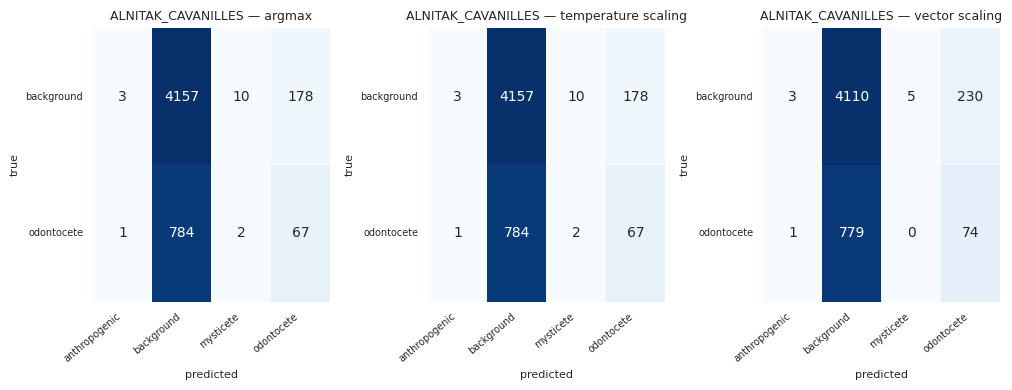


  Adriatic_Sea  |  T=1.262  |  classes present: ['background', 'odontocete']
  metric                                    argmax      temp       vec
  --------------------------------------------------------------------
  macro F1 (test classes)                    0.665     0.665     0.676
  balanced accuracy                          0.799     0.799     0.798
  --- species rows only ---             
  species recall (macro)                     0.627     0.627     0.651
  species precision (macro)                  1.000     1.000     1.000
  species macro F1                           0.771     0.771     0.788
  inter-species confusion (vocab-wide)       0.000     0.000     0.002
  hallucination (absent species predicted)     0.000     0.000     0.002


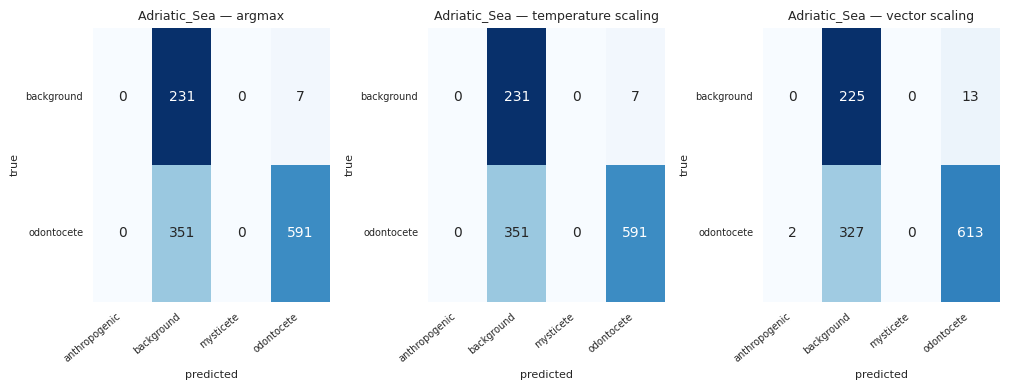


  DCLDE_2026  |  T=0.883  |  classes present: ['background', 'odontocete']
  metric                                    argmax      temp       vec
  --------------------------------------------------------------------
  macro F1 (test classes)                    0.556     0.556     0.585
  balanced accuracy                          0.598     0.598     0.605
  --- species rows only ---             
  species recall (macro)                     0.521     0.521     0.502
  species precision (macro)                  1.000     1.000     1.000
  species macro F1                           0.685     0.685     0.669
  inter-species confusion (vocab-wide)       0.017     0.017     0.024
  hallucination (absent species predicted)     0.017     0.017     0.024


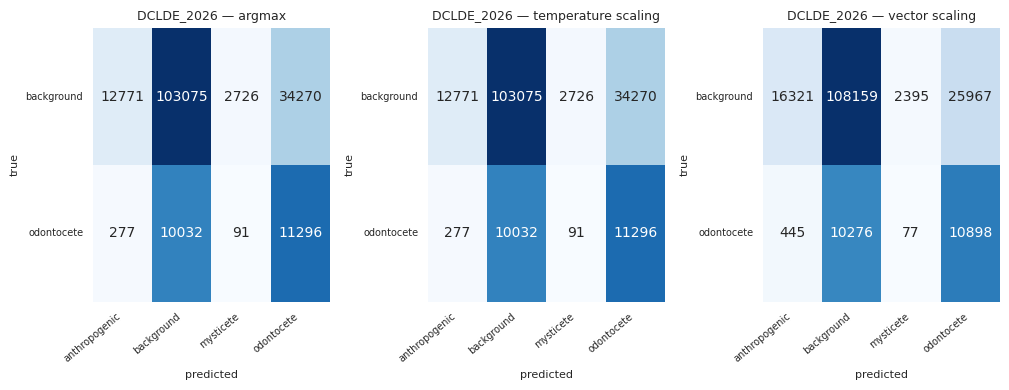


  DOLPHINFREE  |  T=1.201  |  classes present: ['background', 'odontocete']
  metric                                    argmax      temp       vec
  --------------------------------------------------------------------
  macro F1 (test classes)                    0.753     0.753     0.702
  balanced accuracy                          0.797     0.797     0.760
  --- species rows only ---             
  species recall (macro)                     0.970     0.970     0.983
  species precision (macro)                  1.000     1.000     1.000
  species macro F1                           0.985     0.985     0.991
  inter-species confusion (vocab-wide)       0.000     0.000     0.001
  hallucination (absent species predicted)     0.000     0.000     0.001


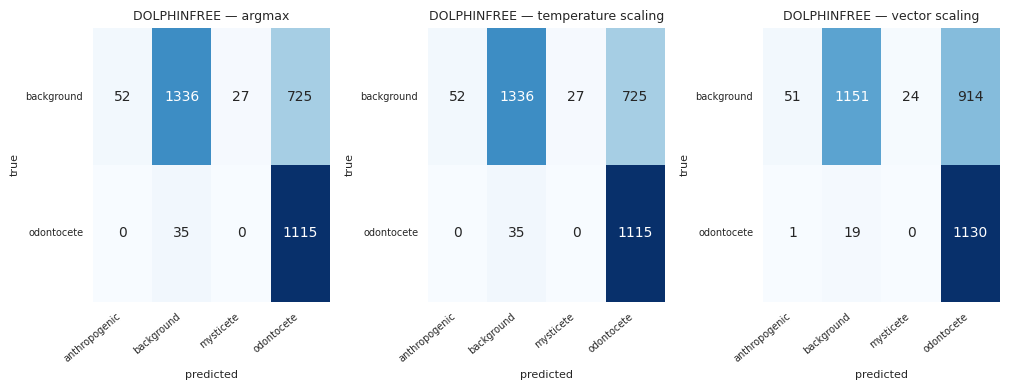


  DRYAD  |  T=1.100  |  classes present: ['background', 'odontocete']
  metric                                    argmax      temp       vec
  --------------------------------------------------------------------
  macro F1 (test classes)                    0.715     0.715     0.702
  balanced accuracy                          0.724     0.724     0.710
  --- species rows only ---             
  species recall (macro)                     0.881     0.881     0.873
  species precision (macro)                  1.000     1.000     1.000
  species macro F1                           0.937     0.937     0.932
  inter-species confusion (vocab-wide)       0.070     0.070     0.083
  hallucination (absent species predicted)     0.070     0.070     0.083


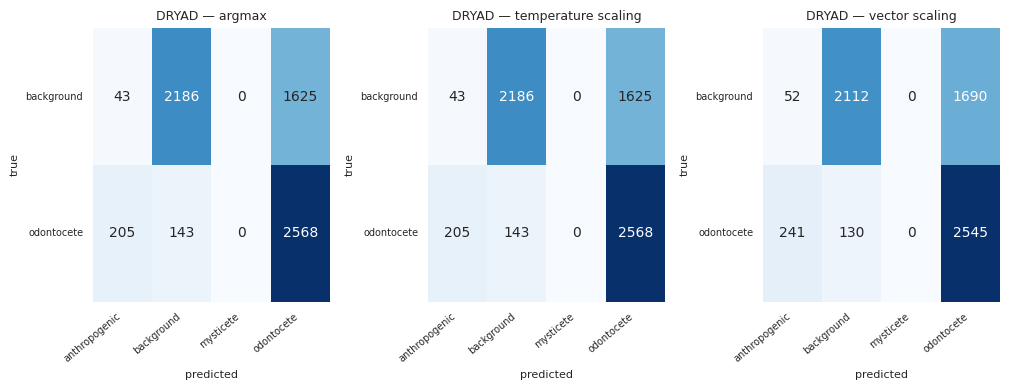


  ECOSS_annot  |  T=1.097  |  classes present: ['anthropogenic', 'odontocete']
  metric                                    argmax      temp       vec
  --------------------------------------------------------------------
  macro F1 (test classes)                    0.229     0.229     0.249
  balanced accuracy                          0.186     0.186     0.194
  --- species rows only ---             
  species recall (macro)                     0.186     0.186     0.194
  species precision (macro)                  0.300     0.300     0.348
  species macro F1                           0.229     0.229     0.249
  inter-species confusion (vocab-wide)       0.153     0.153     0.105
  hallucination (absent species predicted)     0.000     0.000     0.000


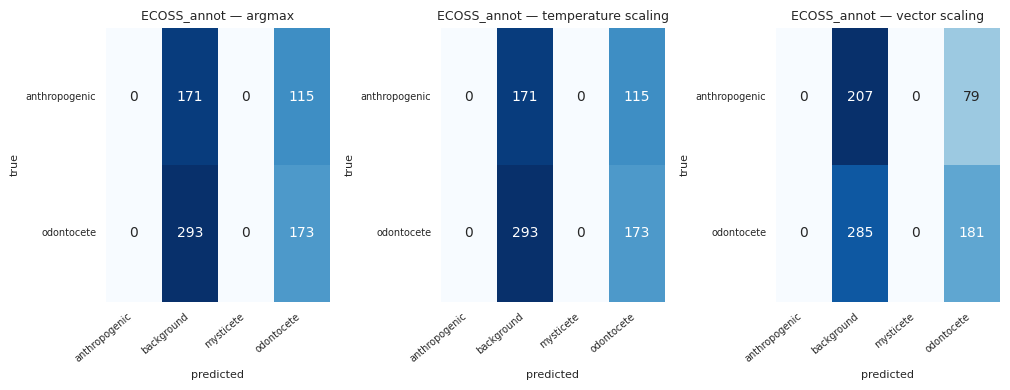


  ECOSS_enhanced  |  T=1.047  |  classes present: ['anthropogenic', 'odontocete']
  metric                                    argmax      temp       vec
  --------------------------------------------------------------------
  macro F1 (test classes)                    0.636     0.636     0.636
  balanced accuracy                          0.577     0.577     0.577
  --- species rows only ---             
  species recall (macro)                     0.577     0.577     0.577
  species precision (macro)                  1.000     1.000     1.000
  species macro F1                           0.636     0.636     0.636
  inter-species confusion (vocab-wide)       0.125     0.125     0.125
  hallucination (absent species predicted)     0.125     0.125     0.125


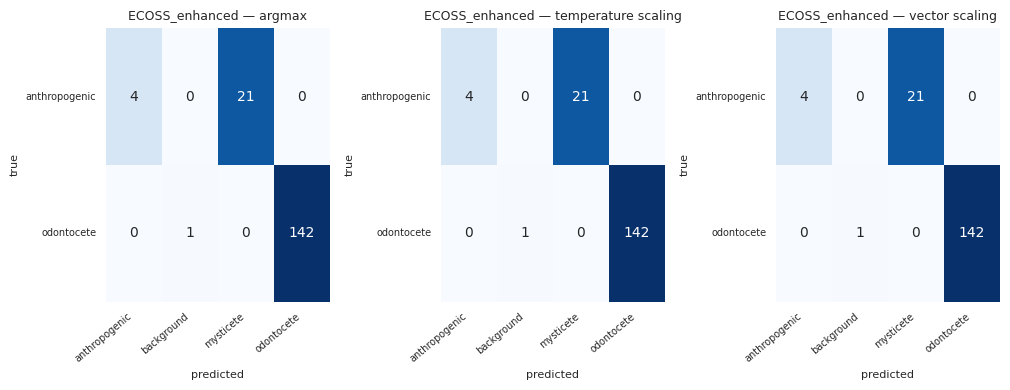


  ECOSS_testtrain  |  T=1.141  |  classes present: ['anthropogenic', 'background', 'odontocete']
  metric                                    argmax      temp       vec
  --------------------------------------------------------------------
  macro F1 (test classes)                    0.057     0.057     0.054
  balanced accuracy                          0.581     0.581     0.585
  --- species rows only ---             
  species recall (macro)                     0.458     0.458     0.465
  species precision (macro)                  0.514     0.514     0.512
  species macro F1                           0.030     0.030     0.025
  inter-species confusion (vocab-wide)       0.124     0.124     0.147
  hallucination (absent species predicted)     0.002     0.002     0.002


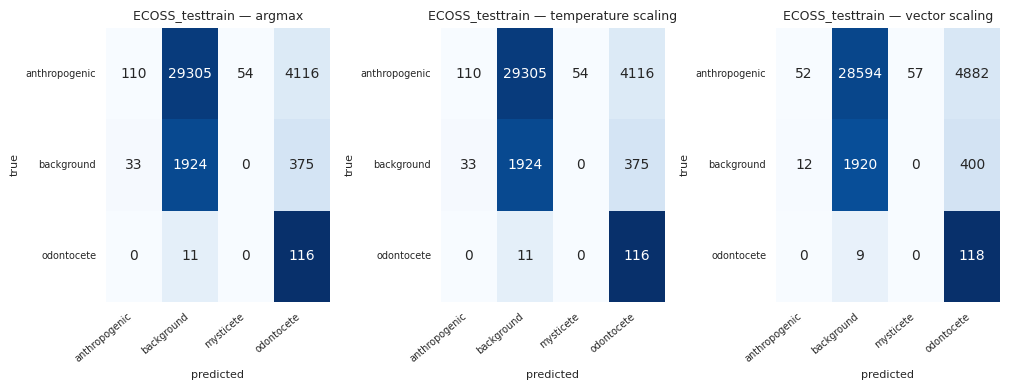


  FREMANTLE  |  T=1.384  |  classes present: ['odontocete']
  metric                                    argmax      temp       vec
  --------------------------------------------------------------------
  macro F1 (test classes)                    0.920     0.920     0.936
  balanced accuracy                          0.852     0.852     0.880
  --- species rows only ---             
  species recall (macro)                     0.852     0.852     0.880
  species precision (macro)                  1.000     1.000     1.000
  species macro F1                           0.920     0.920     0.936
  inter-species confusion (vocab-wide)       0.000     0.000     0.000
  hallucination (absent species predicted)     0.000     0.000     0.000


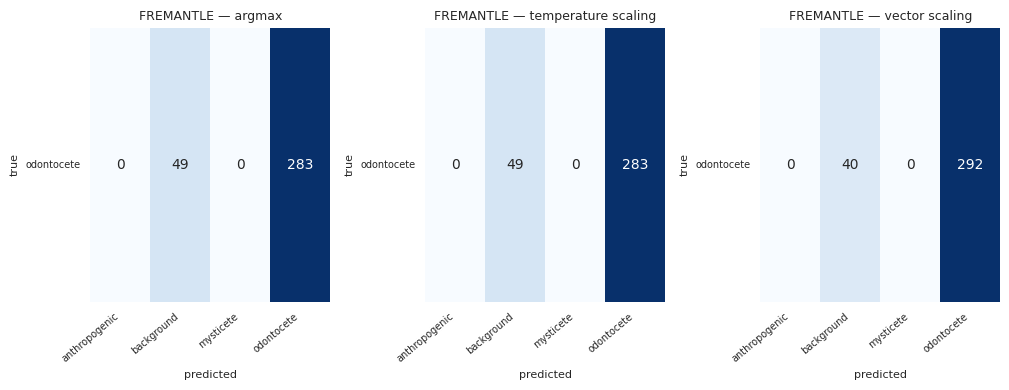


  MONISH  |  T=1.058  |  classes present: ['mysticete', 'odontocete']
  metric                                    argmax      temp       vec
  --------------------------------------------------------------------
  macro F1 (test classes)                    0.447     0.447     0.447
  balanced accuracy                          0.424     0.424     0.423
  --- species rows only ---             
  species recall (macro)                     0.424     0.424     0.423
  species precision (macro)                  0.473     0.473     0.472
  species macro F1                           0.447     0.447     0.447
  inter-species confusion (vocab-wide)       0.076     0.076     0.079
  hallucination (absent species predicted)     0.029     0.029     0.032


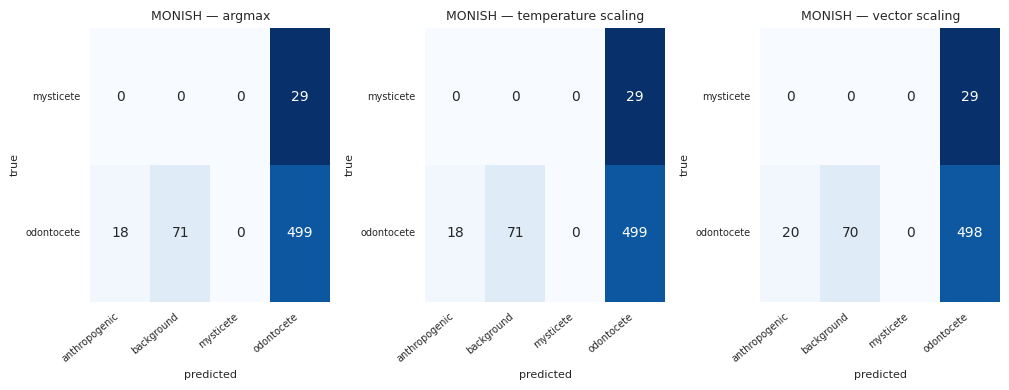


  OLTREMARE  |  T=1.117  |  classes present: ['background', 'odontocete']
  metric                                    argmax      temp       vec
  --------------------------------------------------------------------
  macro F1 (test classes)                    0.792     0.792     0.802
  balanced accuracy                          0.817     0.817     0.819
  --- species rows only ---             
  species recall (macro)                     0.734     0.734     0.724
  species precision (macro)                  1.000     1.000     1.000
  species macro F1                           0.846     0.846     0.840
  inter-species confusion (vocab-wide)       0.000     0.000     0.000
  hallucination (absent species predicted)     0.000     0.000     0.000


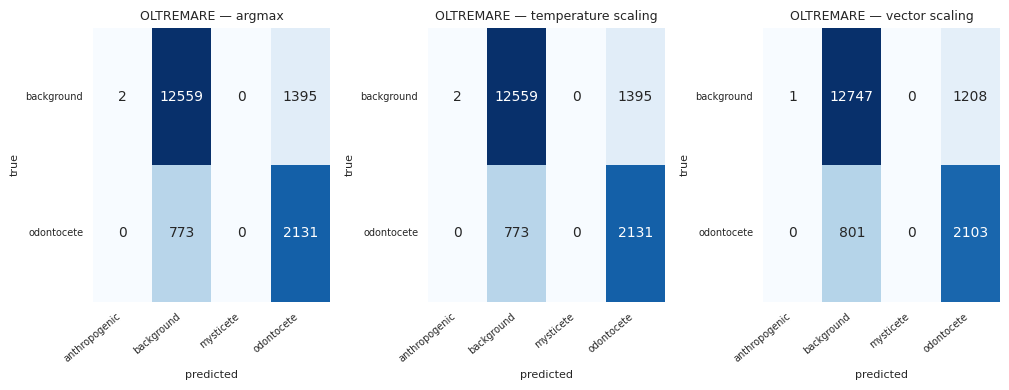


  WATKINS  |  T=1.492  |  classes present: ['mysticete', 'odontocete']
  metric                                    argmax      temp       vec
  --------------------------------------------------------------------
  macro F1 (test classes)                    0.468     0.468     0.476
  balanced accuracy                          0.440     0.440     0.454
  --- species rows only ---             
  species recall (macro)                     0.440     0.440     0.454
  species precision (macro)                  0.500     0.500     0.500
  species macro F1                           0.468     0.468     0.476
  inter-species confusion (vocab-wide)       0.090     0.090     0.102
  hallucination (absent species predicted)     0.090     0.090     0.102


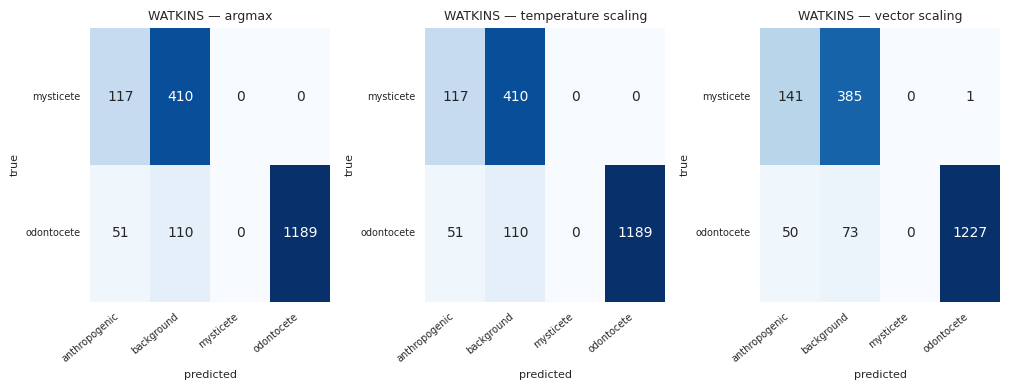

In [15]:
for ds, r in results_l2.items():
    report_fold(r, bg_label='background')

In [16]:
summary_l2 = make_summary_df(results_l2, 'L2-coarse')
print(summary_l2[[
    'held_out','n_test','n_classes_test',
    'argmax_sp_recall','vec_sp_recall',
    'argmax_sp_prec','vec_sp_prec',
    'argmax_sp_f1','vec_sp_f1',
    'argmax_inter_conf','vec_inter_conf',
    'argmax_hallucin','vec_hallucin'
]].to_string(index=False))
summary_l2.to_csv(OUT_DIR / 'summary_l2.csv', index=False)

          held_out  n_test  n_classes_test  argmax_sp_recall  vec_sp_recall  argmax_sp_prec  vec_sp_prec  argmax_sp_f1  vec_sp_f1  argmax_inter_conf  vec_inter_conf  argmax_hallucin  vec_hallucin
       DOLPHINFREE    3290               2          0.969565       0.982609        1.000000     1.000000      0.984547   0.991228           0.000000        0.000870         0.000000      0.000870
         FREMANTLE     332               1          0.852410       0.879518        1.000000     1.000000      0.920325   0.935897           0.000000        0.000000         0.000000      0.000000
             DRYAD    6770               2          0.880658       0.872771        1.000000     1.000000      0.936543   0.932064           0.070302        0.082647         0.070302      0.082647
         OLTREMARE   16860               2          0.733815       0.724174        1.000000     1.000000      0.846475   0.840024           0.000000        0.000000         0.000000      0.000000
      Adriatic_Sea  

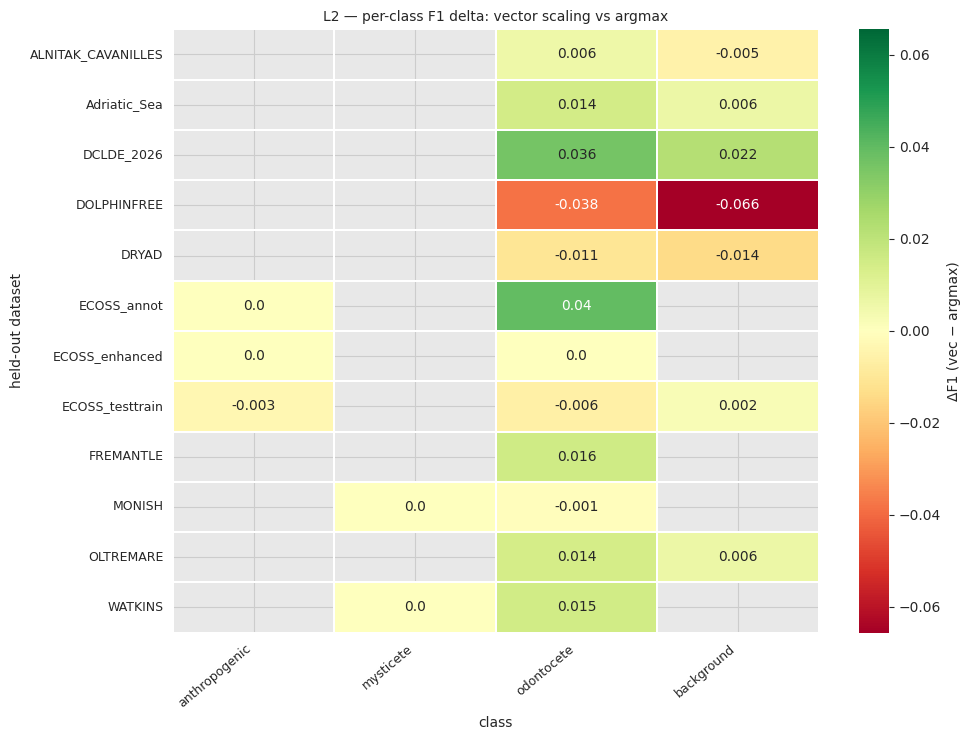


Mean ΔF1 per class (vec − argmax):
class
background      -0.007
anthropogenic   -0.001
mysticete        0.000
odontocete       0.007


In [17]:
_ = per_class_delta_heatmap(
    results_l2, 'vec', 'argmax',
    title='L2 — per-class F1 delta: vector scaling vs argmax',
    out_path=OUT_DIR / 'l2_vec_delta_heatmap.png',
    bg_label='background'
)

## 9. Level 4 — species LODO

86% background, 10 species. Vector scaling calibrated on species-positive
val rows only. The `w` heatmap shows how much each species was sharpened
(`w > 1`) or flattened (`w < 1`) — background should consistently show `w < 1`
and rare species should show `w > 1` if the calibration is working correctly.

In [18]:
L4_HOLDOUTS = sorted(meta_l4['dataset'].unique().tolist())
print(f"{len(L4_HOLDOUTS)} holdouts: {L4_HOLDOUTS}")
results_l4 = run_lodo_level(
    meta_l4, 'label', 'L4-species', L4_HOLDOUTS,
    bg_label='background',
    species_only_fit=True,
    verbose=True
)

12 holdouts: ['ALNITAK_CAVANILLES', 'Adriatic_Sea', 'DCLDE_2026', 'DOLPHINFREE', 'DRYAD', 'ECOSS_annot', 'ECOSS_enhanced', 'ECOSS_testtrain', 'FREMANTLE', 'MONISH', 'OLTREMARE', 'WATKINS']


L4-species LODO:   0%|          | 0/12 [00:00<?, ?it/s]


  [ALNITAK_CAVANILLES] train classes (11): ['Balaenoptera_acutorostrata', 'Balaenoptera_physalus', 'Delphinidae_unknown', 'Delphinus_delphis', 'Globicephala_melas', 'Grampus_griseus', 'Orcinus_orca', 'Physeter_macrocephalus', 'Stenella_coeruleoalba', 'Tursiops_truncatus', 'background']
  [ALNITAK_CAVANILLES] test composition:
      background                          n= 4,348  (OK)
      Physeter_macrocephalus              n=   179  (OK)
      Globicephala_melas                  n=   141  (OK)
      Tursiops_truncatus                  n=    58  (OK)
      Grampus_griseus                     n=    45  (OK)
      Stenella_coeruleoalba               n=    15  (OK)
  [ALNITAK_CAVANILLES] train=211,477  val=30,951  (sp_val=4,148)  test=4,786
  [ALNITAK_CAVANILLES] T=1.260  (softening)
  [ALNITAK_CAVANILLES] vector scales (species-only val):
      Balaenoptera_acutorostrata           w=+1.074  b=-0.073
      Balaenoptera_physalus                w=+1.048  b=-0.022
      Delphinidae_unknown  


  ALNITAK_CAVANILLES  |  T=1.260  |  classes present: ['Globicephala_melas', 'Grampus_griseus', 'Physeter_macrocephalus', 'Stenella_coeruleoalba', 'Tursiops_truncatus', 'background']
  metric                                    argmax      temp       vec
  --------------------------------------------------------------------
  macro F1 (test classes)                    0.175     0.175     0.182
  balanced accuracy                          0.171     0.171     0.174
  --- species rows only ---             
  species recall (macro)                     0.012     0.012     0.018
  species precision (macro)                  0.400     0.400     0.173
  species macro F1                           0.023     0.023     0.033
  inter-species confusion (vocab-wide)       0.087     0.087     0.105
  hallucination (absent species predicted)     0.066     0.066     0.071


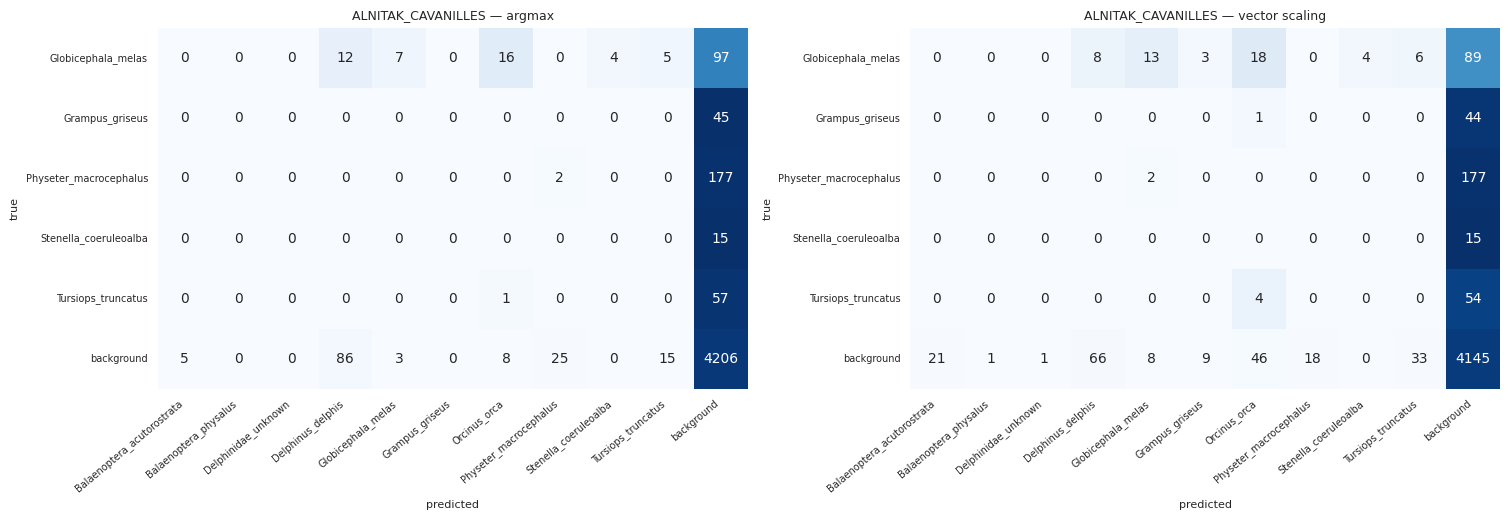


  Adriatic_Sea  |  T=1.385  |  classes present: ['Tursiops_truncatus', 'background']
  metric                                    argmax      temp       vec
  --------------------------------------------------------------------
  macro F1 (test classes)                    0.692     0.692     0.654
  balanced accuracy                          0.705     0.705     0.621
  --- species rows only ---             
  species recall (macro)                     0.620     0.620     0.570
  species precision (macro)                  1.000     1.000     1.000
  species macro F1                           0.765     0.765     0.726
  inter-species confusion (vocab-wide)       0.209     0.209     0.299
  hallucination (absent species predicted)     0.209     0.209     0.299


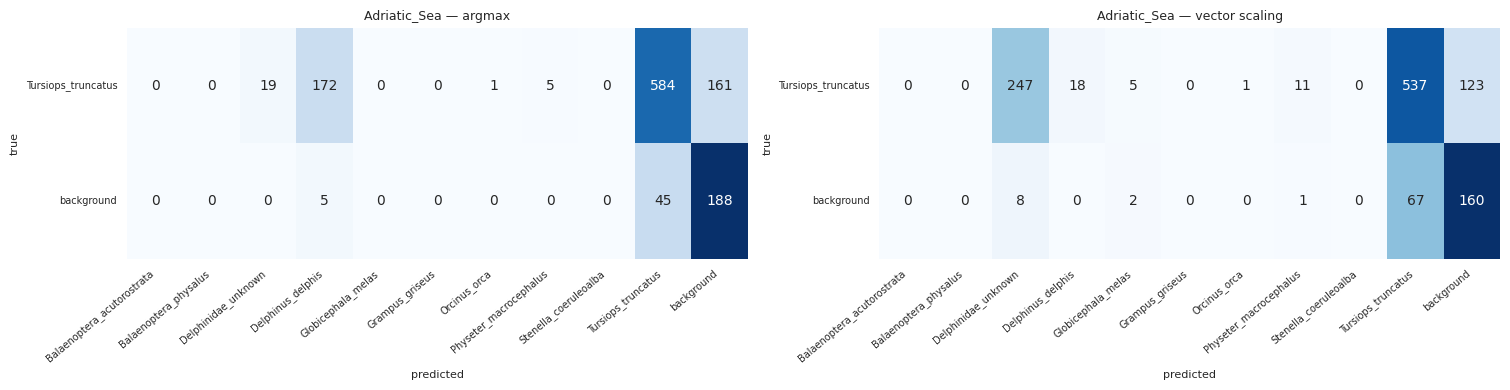


  DCLDE_2026  |  T=1.795  |  classes present: ['Orcinus_orca', 'background']
  metric                                    argmax      temp       vec
  --------------------------------------------------------------------
  macro F1 (test classes)                    0.534     0.534     0.346
  balanced accuracy                          0.431     0.431     0.245
  --- species rows only ---             
  species recall (macro)                     0.229     0.229     0.241
  species precision (macro)                  1.000     1.000     1.000
  species macro F1                           0.372     0.372     0.388
  inter-species confusion (vocab-wide)       0.463     0.463     0.660
  hallucination (absent species predicted)     0.463     0.463     0.660


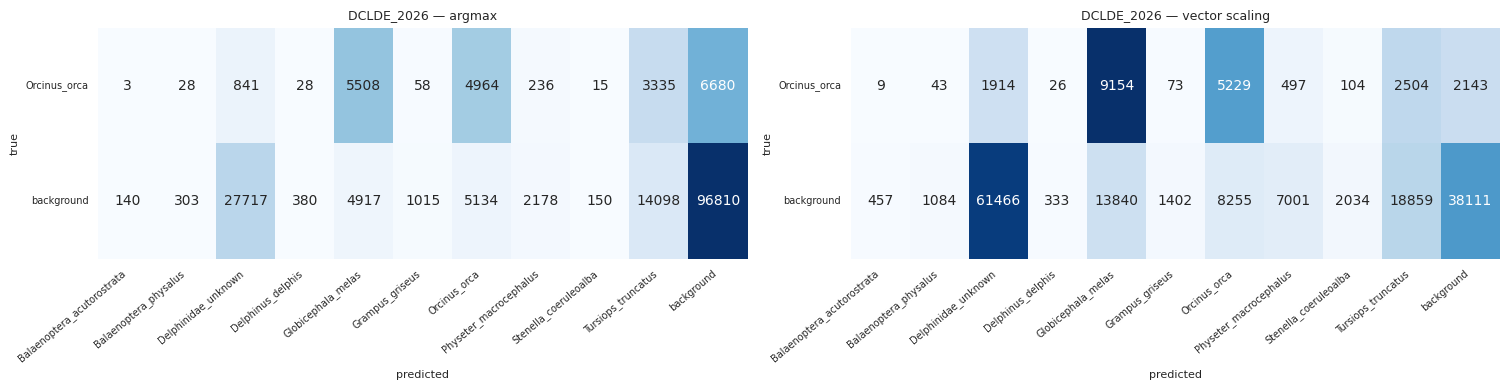


  DOLPHINFREE  |  T=1.446  |  classes present: ['Delphinus_delphis', 'background']
  metric                                    argmax      temp       vec
  --------------------------------------------------------------------
  macro F1 (test classes)                    0.387     0.387     0.465
  balanced accuracy                          0.304     0.304     0.339
  --- species rows only ---             
  species recall (macro)                     0.036     0.036     0.460
  species precision (macro)                  1.000     1.000     1.000
  species macro F1                           0.069     0.069     0.630
  inter-species confusion (vocab-wide)       0.871     0.871     0.530
  hallucination (absent species predicted)     0.871     0.871     0.530


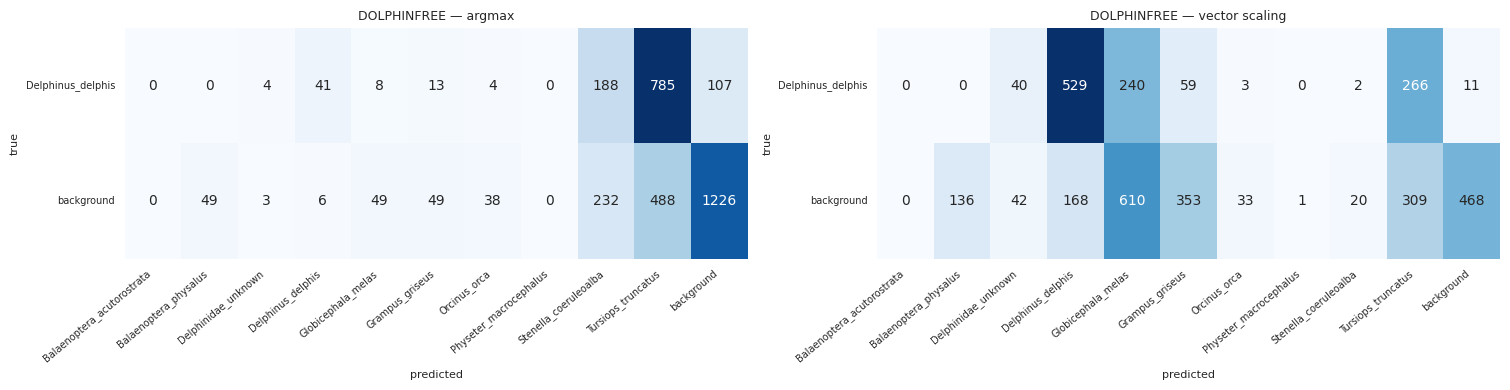


  DRYAD  |  T=1.373  |  classes present: ['Tursiops_truncatus', 'background']
  metric                                    argmax      temp       vec
  --------------------------------------------------------------------
  macro F1 (test classes)                    0.682     0.682     0.661
  balanced accuracy                          0.611     0.611     0.585
  --- species rows only ---             
  species recall (macro)                     0.626     0.626     0.615
  species precision (macro)                  1.000     1.000     1.000
  species macro F1                           0.770     0.770     0.761
  inter-species confusion (vocab-wide)       0.278     0.278     0.296
  hallucination (absent species predicted)     0.278     0.278     0.296


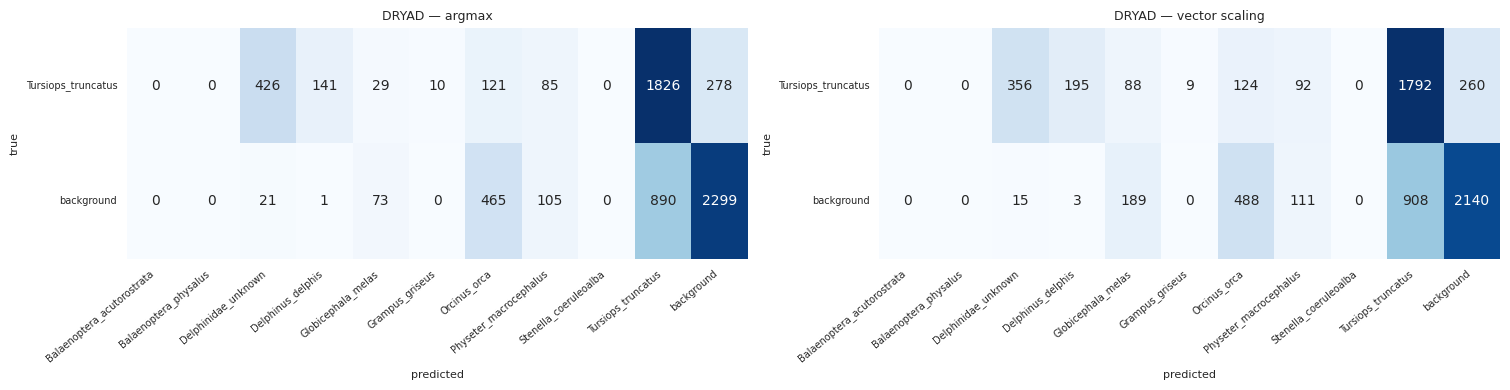


  ECOSS_annot  |  T=1.388  |  classes present: ['Delphinidae_unknown', 'background']
  metric                                    argmax      temp       vec
  --------------------------------------------------------------------
  macro F1 (test classes)                    0.315     0.315     0.186
  balanced accuracy                          0.371     0.371     0.177
  --- species rows only ---             
  species recall (macro)                     0.000     0.000     0.000
  species precision (macro)                  0.000     0.000     0.000
  species macro F1                           0.000     0.000     0.000
  inter-species confusion (vocab-wide)       0.622     0.622     0.663
  hallucination (absent species predicted)     0.622     0.622     0.663


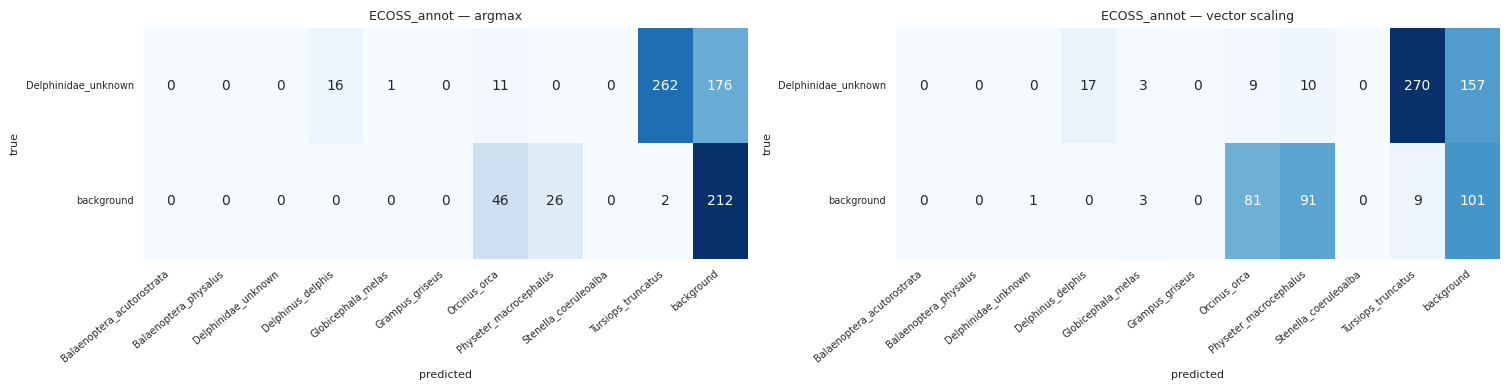


  ECOSS_enhanced  |  T=1.657  |  classes present: ['Delphinidae_unknown', 'Orcinus_orca', 'Physeter_macrocephalus', 'Stenella_coeruleoalba', 'Tursiops_truncatus', 'background']
  metric                                    argmax      temp       vec
  --------------------------------------------------------------------
  macro F1 (test classes)                    0.517     0.517     0.529
  balanced accuracy                          0.503     0.503     0.509
  --- species rows only ---             
  species recall (macro)                     0.572     0.572     0.579
  species precision (macro)                  0.565     0.565     0.588
  species macro F1                           0.568     0.568     0.583
  inter-species confusion (vocab-wide)       0.608     0.608     0.601
  hallucination (absent species predicted)     0.580     0.580     0.587


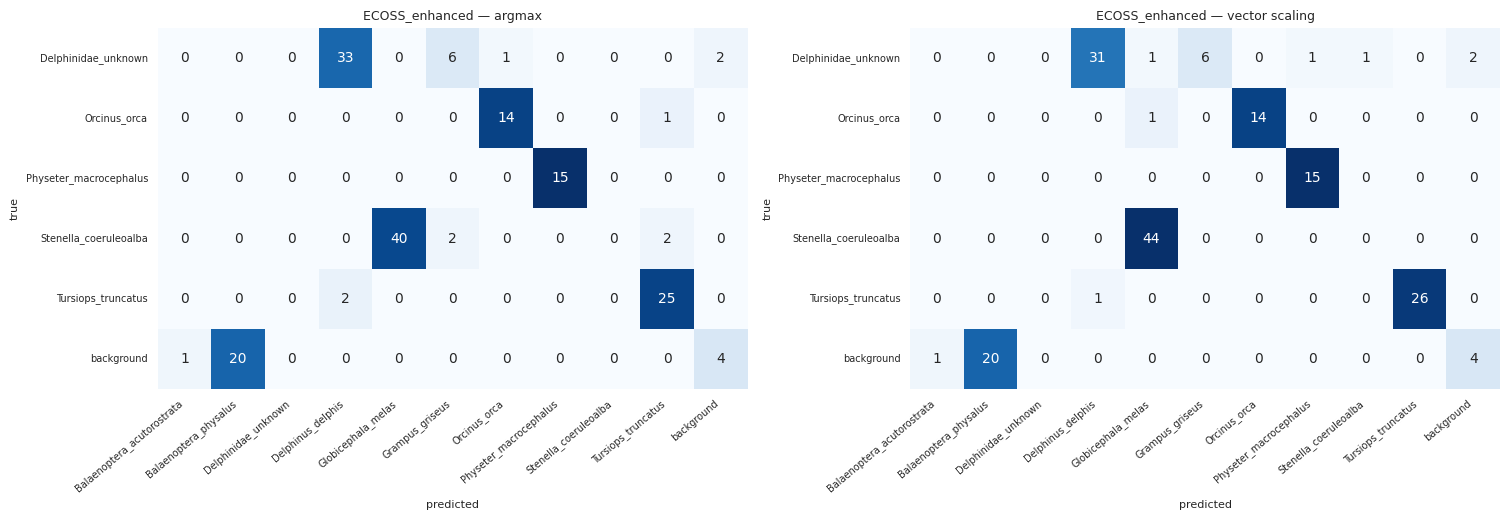


  ECOSS_testtrain  |  T=1.610  |  classes present: ['Delphinus_delphis', 'Globicephala_melas', 'Orcinus_orca', 'Physeter_macrocephalus', 'Tursiops_truncatus', 'background']
  metric                                    argmax      temp       vec
  --------------------------------------------------------------------
  macro F1 (test classes)                    0.232     0.232     0.226
  balanced accuracy                          0.604     0.604     0.617
  --- species rows only ---             
  species recall (macro)                     0.532     0.532     0.569
  species precision (macro)                  0.657     0.657     0.692
  species macro F1                           0.495     0.495     0.585
  inter-species confusion (vocab-wide)       0.520     0.520     0.472
  hallucination (absent species predicted)     0.362     0.362     0.370


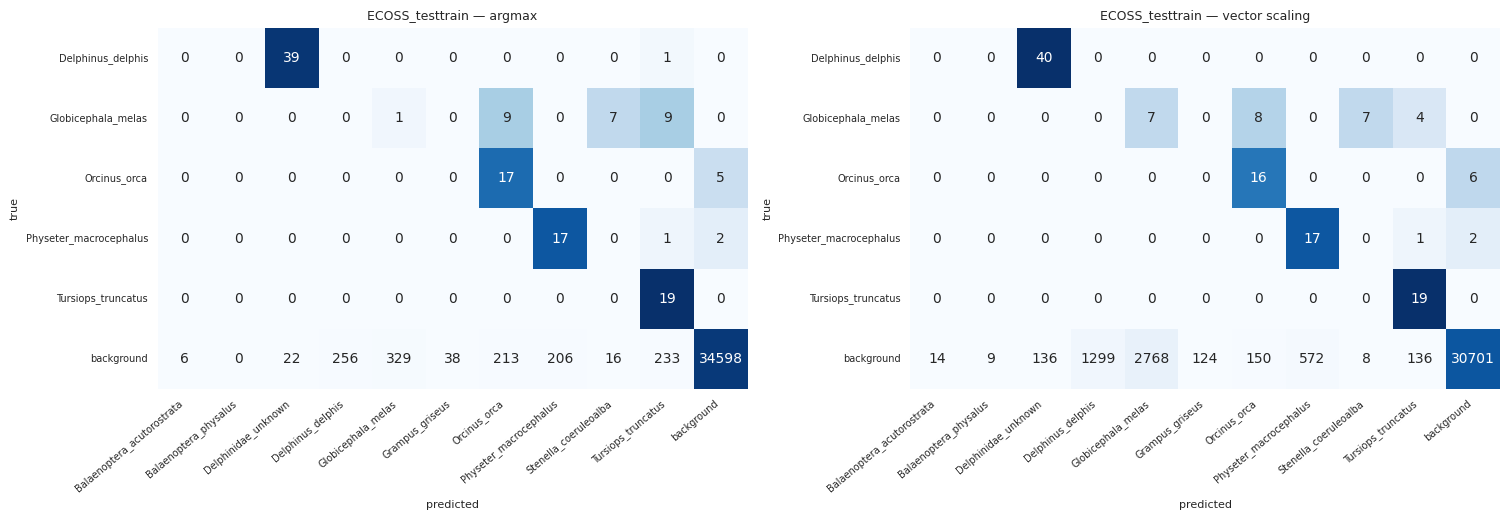


  FREMANTLE  |  T=1.978  |  classes present: ['Tursiops_truncatus']
  metric                                    argmax      temp       vec
  --------------------------------------------------------------------
  macro F1 (test classes)                    0.528     0.528     0.491
  balanced accuracy                          0.358     0.358     0.325
  --- species rows only ---             
  species recall (macro)                     0.358     0.358     0.325
  species precision (macro)                  1.000     1.000     1.000
  species macro F1                           0.528     0.528     0.491
  inter-species confusion (vocab-wide)       0.455     0.455     0.554
  hallucination (absent species predicted)     0.455     0.455     0.554


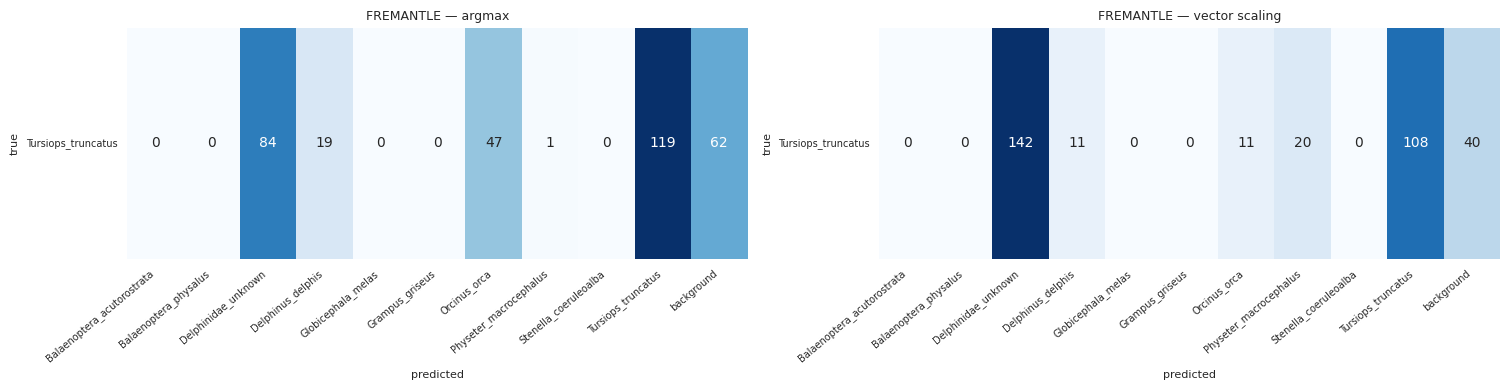


  MONISH  |  T=1.723  |  classes present: ['Balaenoptera_physalus', 'Globicephala_melas', 'Grampus_griseus', 'Orcinus_orca', 'Tursiops_truncatus']
  metric                                    argmax      temp       vec
  --------------------------------------------------------------------
  macro F1 (test classes)                    0.076     0.076     0.115
  balanced accuracy                          0.155     0.155     0.202
  --- species rows only ---             
  species recall (macro)                     0.155     0.155     0.202
  species precision (macro)                  0.178     0.178     0.192
  species macro F1                           0.076     0.076     0.115
  inter-species confusion (vocab-wide)       0.712     0.712     0.859
  hallucination (absent species predicted)     0.230     0.230     0.337


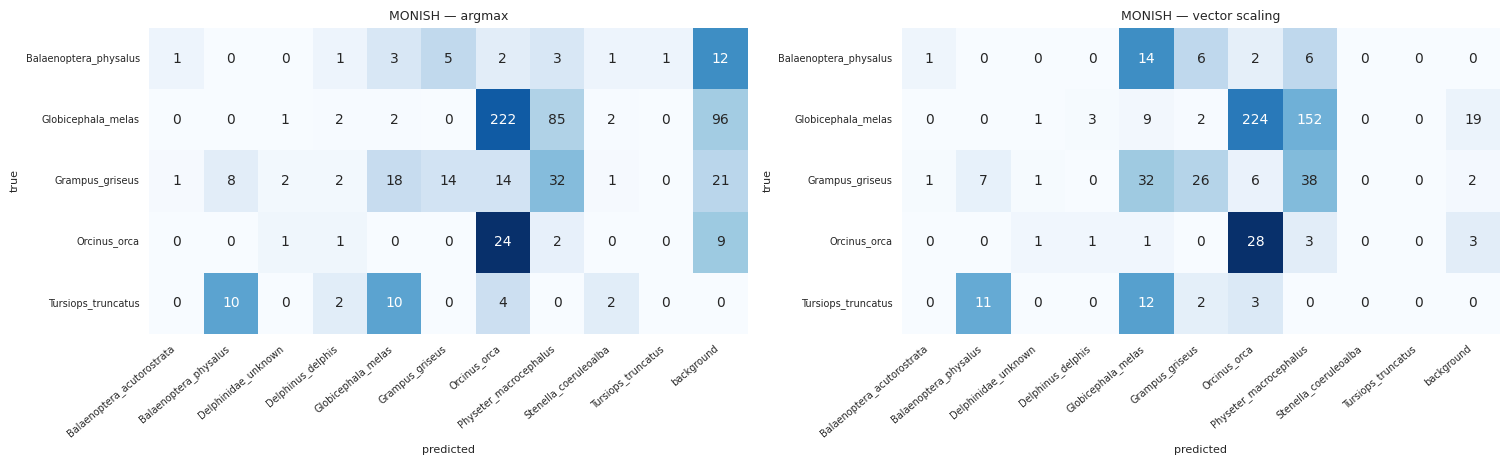


  OLTREMARE  |  T=1.380  |  classes present: ['Tursiops_truncatus', 'background']
  metric                                    argmax      temp       vec
  --------------------------------------------------------------------
  macro F1 (test classes)                    0.823     0.823     0.669
  balanced accuracy                          0.804     0.804     0.774
  --- species rows only ---             
  species recall (macro)                     0.668     0.668     0.845
  species precision (macro)                  1.000     1.000     1.000
  species macro F1                           0.801     0.801     0.916
  inter-species confusion (vocab-wide)       0.017     0.017     0.012
  hallucination (absent species predicted)     0.017     0.017     0.012


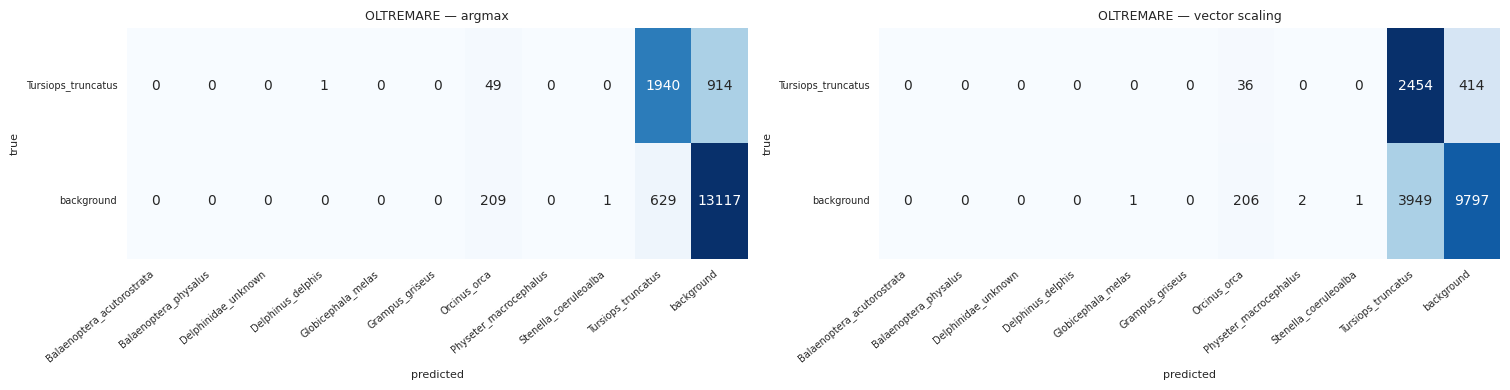


  WATKINS  |  T=1.748  |  classes present: ['Balaenoptera_physalus', 'Delphinus_delphis', 'Globicephala_melas', 'Grampus_griseus', 'Orcinus_orca', 'Physeter_macrocephalus', 'Stenella_coeruleoalba', 'Tursiops_truncatus']
  metric                                    argmax      temp       vec
  --------------------------------------------------------------------
  macro F1 (test classes)                    0.185     0.185     0.220
  balanced accuracy                          0.376     0.376     0.385
  --- species rows only ---             
  species recall (macro)                     0.376     0.376     0.385
  species precision (macro)                  0.236     0.236     0.259
  species macro F1                           0.185     0.185     0.220
  inter-species confusion (vocab-wide)       0.395     0.395     0.432
  hallucination (absent species predicted)     0.016     0.016     0.024


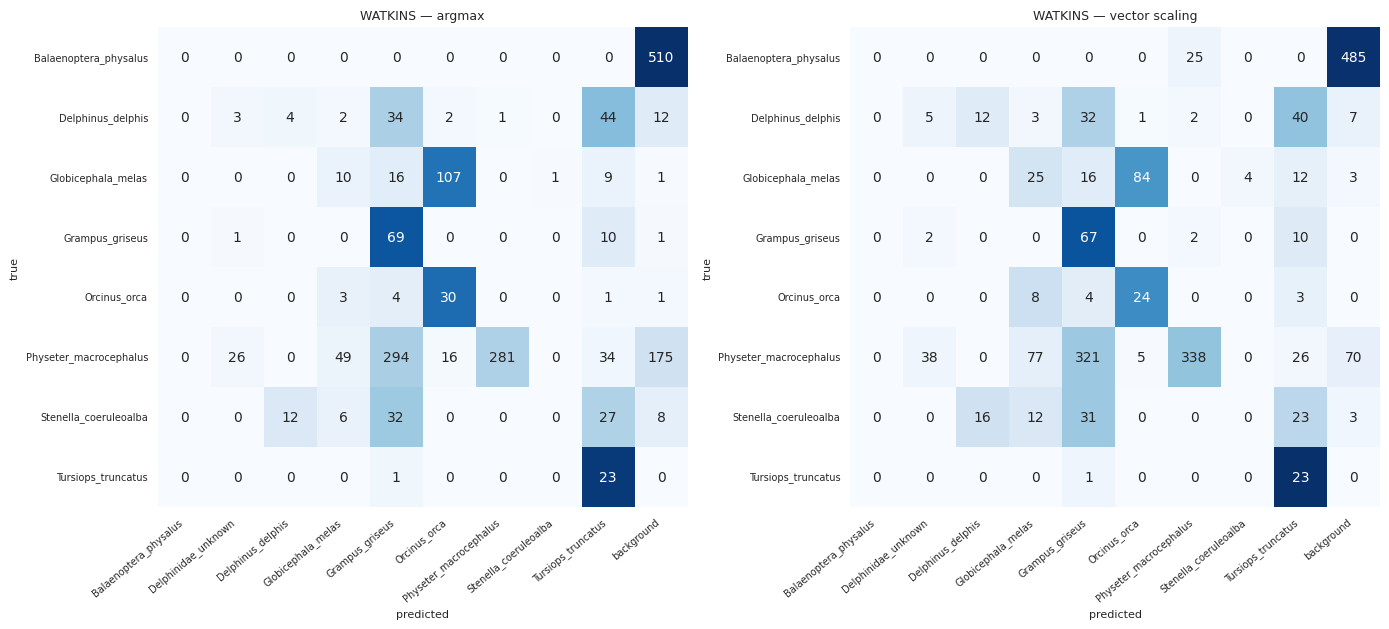

In [20]:
for ds, r in results_l4.items():
    report_fold(r, bg_label='background')

In [21]:
summary_l4 = make_summary_df(results_l4, 'L4-species')
print("\nLevel 4 — species-only metrics (vocab-wide confusion):")
print(summary_l4[[
    'held_out','n_test','n_classes_test','sp_n_rows',
    'argmax_sp_recall','vec_sp_recall',
    'argmax_sp_prec','vec_sp_prec',
    'argmax_sp_f1','vec_sp_f1',
    'argmax_inter_conf','vec_inter_conf',
    'argmax_hallucin','vec_hallucin',
    'temperature',
]].to_string(index=False))
summary_l4.to_csv(OUT_DIR / 'summary_l4.csv', index=False)


Level 4 — species-only metrics (vocab-wide confusion):
          held_out  n_test  n_classes_test  sp_n_rows  argmax_sp_recall  vec_sp_recall  argmax_sp_prec  vec_sp_prec  argmax_sp_f1  vec_sp_f1  argmax_inter_conf  vec_inter_conf  argmax_hallucin  vec_hallucin  temperature
         OLTREMARE   16860               2       2904          0.668044       0.845041        1.000000     1.000000      0.800991   0.916013           0.017218        0.012397         0.017218      0.012397        1.380
             DRYAD    6770               2       2916          0.626200       0.614540        1.000000     1.000000      0.770139   0.761257           0.278464        0.296296         0.278464      0.296296        1.373
      Adriatic_Sea    1180               2        942          0.619958       0.570064        1.000000     1.000000      0.765400   0.726166           0.209130        0.299363         0.209130      0.299363        1.385
       DOLPHINFREE    3290               2       1150          0

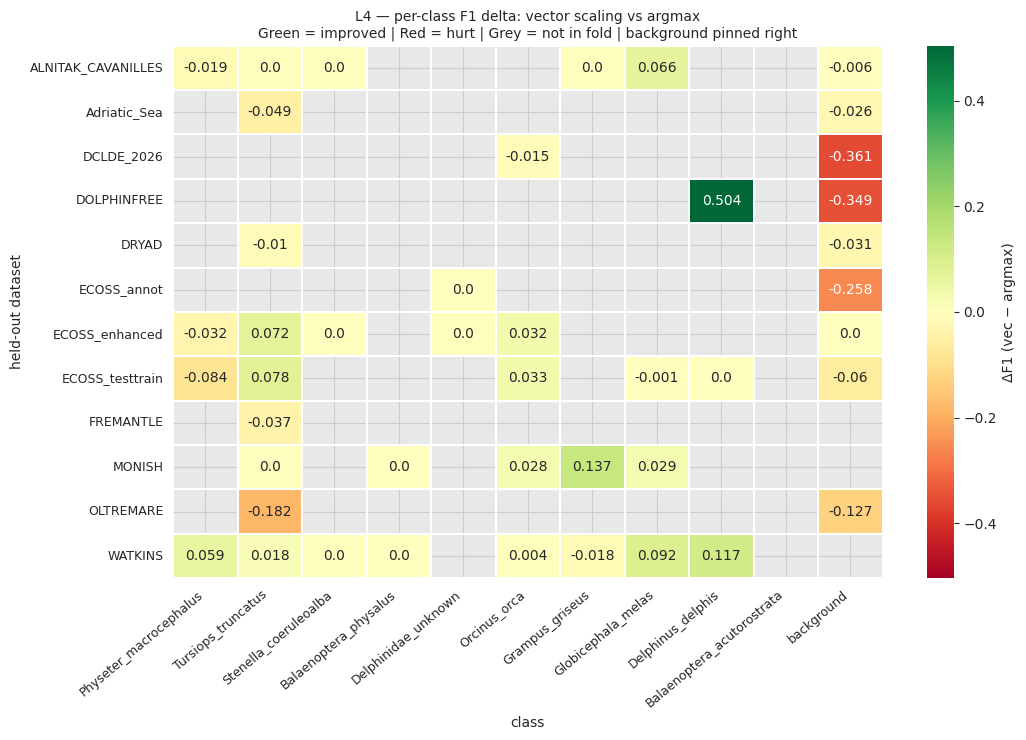


Mean ΔF1 per class (vec − argmax):
class
background                   -0.135
Physeter_macrocephalus       -0.019
Tursiops_truncatus           -0.012
Stenella_coeruleoalba         0.000
Delphinidae_unknown           0.000
Balaenoptera_physalus         0.000
Orcinus_orca                  0.017
Grampus_griseus               0.040
Globicephala_melas            0.047
Delphinus_delphis             0.207
Balaenoptera_acutorostrata      NaN


In [22]:
_ = per_class_delta_heatmap(
    results_l4, 'vec', 'argmax',
    title='L4 — per-class F1 delta: vector scaling vs argmax\n'
          'Green = improved | Red = hurt | Grey = not in fold | background pinned right',
    out_path=OUT_DIR / 'l4_vec_delta_heatmap.png',
    bg_label='background'
)

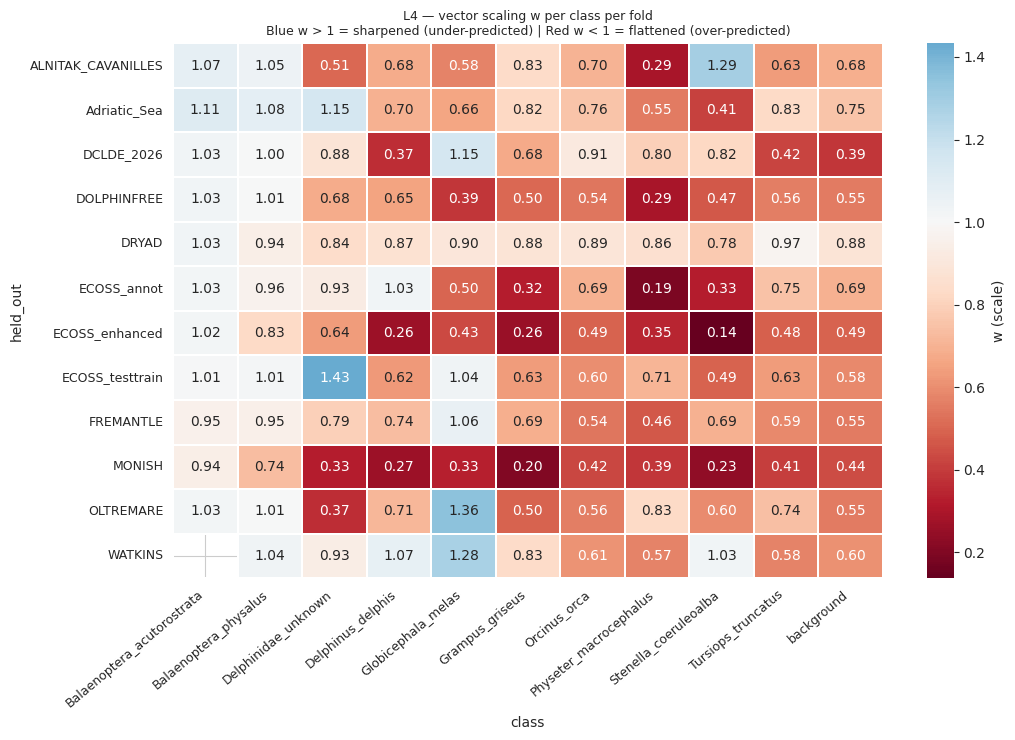

In [23]:
# ── Vector w heatmap ─────────────────────────────────────────────────────────
w_rows = []
for ds, r in results_l4.items():
    for c_name, w_val in zip(r['class_names'], r['vec_w']):
        w_rows.append({'held_out': ds, 'class': c_name, 'w': float(w_val)})

w_pivot = pd.DataFrame(w_rows).pivot(index='held_out', columns='class', values='w')
sp_cols = [c for c in w_pivot.columns if c != 'background']
w_pivot = w_pivot[sorted(sp_cols) + (['background'] if 'background' in w_pivot.columns else [])]

fig, ax = plt.subplots(figsize=(max(10, 0.8*len(w_pivot.columns)+2),
                                 max(5, 0.5*len(w_pivot)+1.5)))
sns.heatmap(w_pivot, cmap='RdBu', center=1.0, annot=True, fmt='.2f',
            linewidths=0.3, ax=ax, cbar_kws={'label': 'w (scale)'})
ax.set_title(
    'L4 — vector scaling w per class per fold\n'
    'Blue w > 1 = sharpened (under-predicted) | Red w < 1 = flattened (over-predicted)',
    fontsize=9)
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'l4_vec_w_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

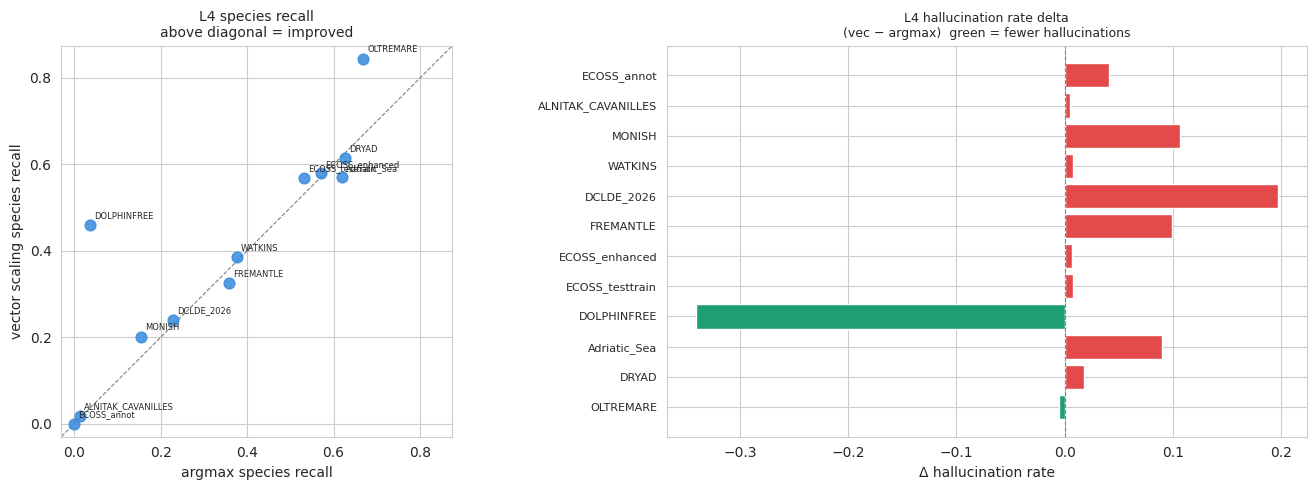

In [24]:
# ── Recall scatter + hallucination scatter ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Recall
ax = axes[0]
sub = summary_l4.dropna(subset=['argmax_sp_recall','vec_sp_recall'])
vmin = min(sub['argmax_sp_recall'].min(), sub['vec_sp_recall'].min()) - 0.03
vmax = max(sub['argmax_sp_recall'].max(), sub['vec_sp_recall'].max()) + 0.03
ax.scatter(sub['argmax_sp_recall'], sub['vec_sp_recall'],
           s=60, color='#378ADD', alpha=0.85, zorder=3)
for _, row in sub.iterrows():
    ax.annotate(row['held_out'], (row['argmax_sp_recall'], row['vec_sp_recall']),
                fontsize=6, ha='left', va='bottom', xytext=(3,3),
                textcoords='offset points')
ax.plot([vmin,vmax],[vmin,vmax],'k--',linewidth=0.8,alpha=0.5)
ax.set_xlim(vmin,vmax); ax.set_ylim(vmin,vmax); ax.set_aspect('equal')
ax.set_xlabel('argmax species recall'); ax.set_ylabel('vector scaling species recall')
ax.set_title('L4 species recall\nabove diagonal = improved', fontsize=10)

# Hallucination
ax = axes[1]
sub2 = summary_l4.dropna(subset=['argmax_hallucin','vec_hallucin'])
colors = ['#E24B4A' if v > a else '#1D9E75'
          for v, a in zip(sub2['vec_hallucin'], sub2['argmax_hallucin'])]
ax.barh(sub2['held_out'],
        sub2['vec_hallucin'] - sub2['argmax_hallucin'],
        color=colors)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title('L4 hallucination rate delta\n(vec − argmax)  green = fewer hallucinations', fontsize=9)
ax.set_xlabel('Δ hallucination rate')
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'l4_recall_hallucin.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# ── Overall mean metrics table ────────────────────────────────────────────────
all_summary = pd.concat([summary_l2, summary_l4], ignore_index=True)
all_summary.to_csv(OUT_DIR / 'summary_all_levels.csv', index=False)

print("Mean species metrics by level and strategy:")
rows_out = []
for level, df in [('L2', summary_l2), ('L4', summary_l4)]:
    for strat, rcol, pcol, fcol, hcol in [
        ('argmax', 'argmax_sp_recall', 'argmax_sp_prec', 'argmax_sp_f1', 'argmax_hallucin'),
        ('temp',   'temp_sp_recall',   'temp_sp_prec',   'temp_sp_f1',   None),
        ('vec',    'vec_sp_recall',    'vec_sp_prec',    'vec_sp_f1',    'vec_hallucin'),
    ]:
        sub = df.dropna(subset=[rcol, pcol, fcol])
        if sub.empty: continue
        row = {'level': level, 'strategy': strat,
               'mean_recall':    round(sub[rcol].mean(), 4),
               'mean_precision': round(sub[pcol].mean(), 4),
               'mean_sp_f1':     round(sub[fcol].mean(), 4)}
        if hcol:
            row['mean_hallucin'] = round(sub[hcol].dropna().mean(), 4)
        rows_out.append(row)
print(pd.DataFrame(rows_out).to_string(index=False))

Mean species metrics by level and strategy:
level strategy  mean_recall  mean_precision  mean_sp_f1  mean_hallucin
   L2   argmax       0.5623          0.8155      0.5917         0.0280
   L2     temp       0.5623          0.8155      0.5917            NaN
   L2      vec       0.5677          0.8193      0.5957         0.0310
   L4   argmax       0.3487          0.6697      0.3878         0.3476
   L4     temp       0.3487          0.6697      0.3878            NaN
   L4      vec       0.4008          0.6586      0.4540         0.3671


## 10. Persist artefacts

In [27]:
def save_preds(name, r):
    rows_te     = r.get('rows_te')
    class_names = r.get('class_names')
    if rows_te is None or class_names is None: return
    df = meta_all.iloc[rows_te][[
        'dataset','region','environment','group_key',
        'label_t1','label_t2','label_t3','label_t4'
    ]].copy()
    df['y_true']   = [class_names[i] for i in r['yte']]
    df['y_argmax'] = [class_names[i] for i in r['y_argmax']]
    df['y_temp']   = [class_names[i] for i in r['y_temp']]
    df['y_vec']    = [class_names[i] for i in r['y_vec']]
    for ci, cn in enumerate(class_names):
        df[f'prob_raw_{cn}'] = r['proba_raw'][:, ci]
        df[f'prob_vec_{cn}'] = r['proba_vec'][:, ci]
    fp = OUT_DIR / f'preds_{name}.parquet'
    df.to_parquet(fp, index=False)
    print(f"  {fp.name}  ({len(df):,} rows)")

print("Level 2:"); [save_preds(f'l2_{ds}', r) for ds, r in results_l2.items()]
print("Level 4:"); [save_preds(f'l4_{ds}', r) for ds, r in results_l4.items()]
print(f"\nAll artefacts → {OUT_DIR.resolve()}")

Level 2:
  preds_l2_ALNITAK_CAVANILLES.parquet  (5,202 rows)
  preds_l2_Adriatic_Sea.parquet  (1,180 rows)
  preds_l2_DCLDE_2026.parquet  (174,538 rows)
  preds_l2_DOLPHINFREE.parquet  (3,290 rows)
  preds_l2_DRYAD.parquet  (6,770 rows)
  preds_l2_ECOSS_annot.parquet  (752 rows)
  preds_l2_ECOSS_enhanced.parquet  (168 rows)
  preds_l2_ECOSS_testtrain.parquet  (36,044 rows)
  preds_l2_FREMANTLE.parquet  (332 rows)
  preds_l2_MONISH.parquet  (617 rows)
  preds_l2_OLTREMARE.parquet  (16,860 rows)
  preds_l2_WATKINS.parquet  (1,877 rows)
Level 4:
  preds_l4_ALNITAK_CAVANILLES.parquet  (4,786 rows)
  preds_l4_Adriatic_Sea.parquet  (1,180 rows)
  preds_l4_DCLDE_2026.parquet  (174,538 rows)
  preds_l4_DOLPHINFREE.parquet  (3,290 rows)
  preds_l4_DRYAD.parquet  (6,770 rows)
  preds_l4_ECOSS_annot.parquet  (752 rows)
  preds_l4_ECOSS_enhanced.parquet  (168 rows)
  preds_l4_ECOSS_testtrain.parquet  (36,044 rows)
  preds_l4_FREMANTLE.parquet  (332 rows)
  preds_l4_MONISH.parquet  (617 rows)
  pre